# 🩺 LC25000 Multi-Model Comparison — Research Benchmark

A unified Google Colab pipeline comparing **12 deep learning architectures** on the LC25000 lung & colon histopathology dataset under **identical conditions** (same data split, same image size, same hyperparameters, same evaluation pipeline).

## Models compared (12 total)
| # | Model | Source | Strategy | Type |
|---|---|---|---|---|
| 1 | **VGG16** | `torchvision` | Frozen features + new classifier | Classic CNN |
| 2 | **ResNet-50** | `torchvision` | Frozen features + new classifier | Classic CNN |
| 3 | **MobileNetV3-Small** | `timm` | Full fine-tune | Efficient CNN |
| 4 | **Vision Transformer (ViT-Base/16)** | `timm` | Full fine-tune | Transformer |
| 5 | **ConvNeXt-Tiny** | `timm` | Full fine-tune | Modern CNN |
| 6 | **FSPAN-Y** (custom existing) | ConvNeXt-Tiny + Y-Block | Frozen backbone + custom head | Hybrid |
| 7 | **EfficientNet-B0** | `timm` | Full fine-tune | Efficient CNN |
| 8 | **EfficientNet-B3** | `timm` | Full fine-tune | Efficient CNN |
| 9 | **Swin-Tiny** | `timm` | Full fine-tune | Hierarchical Transformer |
| 10 | **DenseNet-121** | `timm` | Full fine-tune | Classic CNN |
| 🆕 11 | **DPCT-Net** (novel) | ConvNeXt-Tiny + Swin-Tiny | Dual frozen backbones + gated fusion | Novel hybrid |
| 🆕 12 | **MSCA-Net** (novel) | ConvNeXt-Tiny multi-scale | Frozen backbone + cascade attention | Novel hybrid |

## New analyses for the paper (added to break the ceiling effect)
- 🆕 **Stain robustness test** — heavy color/stain jitter on test set; models that hold accuracy under perturbation = real-world useful
- 🆕 **Efficiency analysis** — params × accuracy × inference time scatter, gives lightweight models a "wins on speed" angle

## Outputs you will get (perfect for a research paper)
- ✅ Accuracy, Precision, Recall, F1-score (macro / weighted / per-class)
- ✅ Support per class
- ✅ Confusion matrices (counts + normalized)
- ✅ Per-class precision/recall/F1 heatmaps
- ✅ Training-curve comparison plots
- ✅ ROC curves & AUC (one-vs-rest)
- ✅ Cohen's kappa & Matthews correlation coefficient
- ✅ McNemar statistical significance test between best models
- ✅ Inference time & parameter count comparison
- ✅ A consolidated CSV results table (`results_summary.csv`) for your paper
- ✅ All figures saved as 300-DPI PNG and PDF (publication-ready)

## How to use (LOCAL — VS Code + RTX 5060)
1. **Install PyTorch with CUDA 12.8** (REQUIRED for Blackwell-architecture RTX 50-series):
   ```
   pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128
   pip install timm scikit-learn matplotlib seaborn pandas tqdm Pillow statsmodels
   ```
2. Open this notebook in **VS Code** with the Jupyter extension.
3. **Edit Section 2.1** to point at your local dataset folder (e.g., `E:\LC25000`).
4. **Edit Section 3.1** to point at your local results folder (e.g., `E:\LC25000_results`). If you copied your existing trained models from Drive here, the resume logic will skip them automatically.
5. Run cells in order. Total runtime ≈ 45–60 min for the 6 remaining models on RTX 5060.

> **🛟 Resume support:** Checkpoints/metrics/figures are saved to your local results folder. If you stop and restart, already-trained models are skipped — Section 6.1 shows what will be skipped vs. trained before any work begins.

> **Tip:** If you hit Colab time/memory limits, reduce `EPOCHS` in Section 3 (e.g., to 5) — the comparison is still valid as long as **all models use the same number of epochs**.


---
# 🪟 Section 0: One-time Local Setup (read this first)

## 0.1 PyTorch with CUDA 12.8 for RTX 5060 (Blackwell)

**Open PowerShell or CMD** (not the notebook) and run:
```
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128
pip install timm scikit-learn matplotlib seaborn pandas tqdm Pillow statsmodels jupyter
```

If the first command fails or shows old versions, use the nightly build:
```
pip install --pre torch torchvision --index-url https://download.pytorch.org/whl/nightly/cu128
```

**Why this matters:** The default `pip install torch` installs the cu126 wheel, which **does not support Blackwell GPUs (sm_120)** and will silently run on CPU. Section 1.3 below catches this and tells you to reinstall.

## 0.2 Bring your existing 6 trained models from Google Drive

If you already ran the Colab notebook and have 6 trained models on Drive, save 4+ hours by copying them:

1. Open Google Drive web → navigate to `MyDrive/LC25000_results/`
2. Right-click the **`LC25000_results`** folder → **Download** (Drive zips it automatically; ~1.2 GB)
3. Extract the zip to `E:\LC25000_results\` so you have this structure:
   ```
   E:\LC25000_results\
       models\        (6 .pth files: VGG16, ResNet50, MobileNetV3, ViT_Base, ConvNeXt_Tiny, FSPAN_Y)
       metrics\       (18 files: 3 per model)
       figures\       (existing figures from your earlier run)
   ```
4. Section 6.1 will detect them and skip training those 6 — only the 6 new models will run.

## 0.3 Open this notebook in VS Code

- Open VS Code → **File → Open Folder** → select the folder containing this notebook
- Click on `LC25000_Multi_Model_Comparison_LOCAL.ipynb` to open it
- Top-right corner: select the Python interpreter where you installed the packages above
- Top-right of the first cell: click **Run All** (or run cells one by one)

---
# ⚙️ Section 1: Setup & Environment

We install all required packages and verify GPU availability. We use **PyTorch + `timm`** for all 6 models — this gives us a single, consistent training/evaluation pipeline (originally some of your notebooks were in TensorFlow; we re-implement those models in PyTorch so the comparison is fair).


### 1.1 Install dependencies

In [1]:
# === Dependencies already installed (see Section 0 instructions). ===
# If you skipped that step, run this in your terminal:
#   pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128
#   pip install timm scikit-learn matplotlib seaborn pandas tqdm Pillow statsmodels

import sys, subprocess
try:
    import timm, sklearn, matplotlib, seaborn, pandas, tqdm, PIL, statsmodels
    print('✅ All packages already installed.')
except ImportError as e:
    missing = str(e).split("'")[1] if "'" in str(e) else str(e)
    print(f'❌ Missing package: {missing}')
    print('   Install it with: pip install ' + missing)

c:\Program Files\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ All packages already installed.


### 1.2 Imports & reproducibility

In [2]:
import os
import json
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from copy import deepcopy

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
import timm

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, cohen_kappa_score, matthews_corrcoef,
    precision_recall_fscore_support
)
from sklearn.preprocessing import label_binarize
from statsmodels.stats.contingency_tables import mcnemar

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# Reproducibility — same seed everywhere so all models see the SAME train/val/test split
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"✅ Imports done. Random seed = {SEED}")

✅ Imports done. Random seed = 42


### 1.3 GPU check

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    capability = torch.cuda.get_device_capability(0)
    print(f"Compute capability: sm_{capability[0]}{capability[1]}")
    # Verify Blackwell support actually works (catches the cu126 vs cu128 footgun)
    try:
        _x = torch.randn(8, 3, 32, 32, device="cuda")
        _m = torch.nn.Conv2d(3, 8, 3, padding=1).cuda()
        _ = _m(_x)
        torch.cuda.synchronize()
        print("✅ GPU compute working — ready to train.")
    except RuntimeError as e:
        if "no kernel image" in str(e):
            print("❌ Blackwell sm_120 mismatch! Reinstall PyTorch with CUDA 12.8:")
            print("   pip install --upgrade torch torchvision --index-url https://download.pytorch.org/whl/cu128")
        raise
else:
    print("⚠️  No GPU detected. Training will be VERY slow.")

Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
Memory: 7.96 GB
Compute capability: sm_120
✅ GPU compute working — ready to train.


---
# 📂 Section 2: Locate the LC25000 Dataset (LOCAL)

Your dataset is already on your local SSD in this layout:

```
E:\LC25000\
    Train and Validation Set\
        colon_aca\
        colon_n\
        lung_aca\
        lung_n\
        lung_scc\
    Test Set\
        colon_aca\
        colon_n\
        lung_aca\
        lung_n\
        lung_scc\
```

We point straight at it — no Drive mount, no local copy step needed since the data is already on fast local SSD.

**5 classes:**
- `colon_aca` — Colon adenocarcinoma
- `colon_n`   — Colon benign tissue
- `lung_aca`  — Lung adenocarcinoma
- `lung_n`    — Lung benign tissue
- `lung_scc`  — Lung squamous cell carcinoma


### 2.1 Set the local dataset path

In [4]:
# === EDIT THIS LINE if your LC25000 folder is somewhere else on your computer ===
DATASET_ROOT = Path(r"E:\LC25000")

TRAIN_VAL_DIR = DATASET_ROOT / "Train and Validation Set"
TEST_DIR      = DATASET_ROOT / "Test Set"

assert DATASET_ROOT.exists(), f"❌ Not found: {DATASET_ROOT}\n   Edit DATASET_ROOT above."
assert TRAIN_VAL_DIR.exists(), f"❌ Not found: {TRAIN_VAL_DIR}"
assert TEST_DIR.exists(),      f"❌ Not found: {TEST_DIR}"

print(f"✅ DATASET_ROOT   = {DATASET_ROOT}")
print(f"✅ TRAIN_VAL_DIR  = {TRAIN_VAL_DIR}")
print(f"✅ TEST_DIR       = {TEST_DIR}")

✅ DATASET_ROOT   = E:\LC25000
✅ TRAIN_VAL_DIR  = E:\LC25000\Train and Validation Set
✅ TEST_DIR       = E:\LC25000\Test Set


### 2.2 Verify the folder layout (class counts)

In [5]:
# Verify each class folder exists inside both Train+Val and Test
EXPECTED_CLASSES = ["colon_aca", "colon_n", "lung_aca", "lung_n", "lung_scc"]
for split_name, split_dir in [("Train+Val", TRAIN_VAL_DIR), ("Test", TEST_DIR)]:
    print(f"\n--- {split_name} ({split_dir.name}) ---")
    for cls in EXPECTED_CLASSES:
        cls_dir = split_dir / cls
        if cls_dir.exists():
            n = sum(1 for f in cls_dir.iterdir() if f.suffix.lower() in {".jpg", ".jpeg", ".png"})
            print(f"  ✓ {cls:<12s} {n:>5d} images")
        else:
            print(f"  ✗ {cls:<12s} MISSING")


--- Train+Val (Train and Validation Set) ---
  ✓ colon_aca     4500 images
  ✓ colon_n       4500 images
  ✓ lung_aca      4500 images
  ✓ lung_n        4500 images
  ✓ lung_scc      4501 images

--- Test (Test Set) ---
  ✓ colon_aca      500 images
  ✓ colon_n        500 images
  ✓ lung_aca       500 images
  ✓ lung_n         500 images
  ✓ lung_scc       499 images


### 2.3 Data is already on local SSD — no copy needed ✅

On Colab we copied from Drive → local Colab disk because Drive reads are slow. On your machine the dataset is already on local SSD, so we skip this step entirely. Your `TRAIN_VAL_DIR` and `TEST_DIR` from cell 2.1 point at the final paths used by the rest of the notebook.

In [6]:
# No-op on local — dataset is already on fast local SSD.
print(f"Dataset paths used by the rest of the notebook:")
print(f"  TRAIN_VAL_DIR = {TRAIN_VAL_DIR}")
print(f"  TEST_DIR      = {TEST_DIR}")

Dataset paths used by the rest of the notebook:
  TRAIN_VAL_DIR = E:\LC25000\Train and Validation Set
  TEST_DIR      = E:\LC25000\Test Set


---
# 🔧 Section 3: Shared Data Pipeline

This is the **most important** section for your research paper: every model is trained and evaluated on the **identical train/val/test split** with the **identical preprocessing**. This is what makes the comparison scientifically fair.

**Split strategy:**
- `Train and Validation Set/` → split 80% train / 20% val (random, seed=42)
- `Test Set/` → used as-is (held-out, untouched during training)

**Settings for all models:**
- Image size: **224 × 224**
- Batch size: **32**
- Epochs: **10** (change `EPOCHS` if you want longer training)
- Learning rate: **1e-4** (AdamW, weight decay 1e-5)
- Same random seed (42) → identical splits across runs and across models


### 3.1 Hyperparameters & resume settings

In [7]:
# === GLOBAL HYPERPARAMETERS — change here, applies to ALL models ===
IMG_SIZE      = 224
BATCH_SIZE    = 32
EPOCHS        = 10           # same as your Colab run for fair comparison
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-5
NUM_WORKERS   = 0            # Must be 0 on Windows (spawn-based multiprocessing crashes DataLoader)
NUM_CLASSES   = 5
CLASS_NAMES   = ['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']

# === RESUME / CHECKPOINTING ===
# This points at your LOCAL results folder. If you copied the LC25000_results folder
# from Google Drive to here, the resume logic will detect already-trained models
# (VGG16, ResNet50, MobileNetV3, ViT_Base, ConvNeXt_Tiny, FSPAN_Y) and SKIP them.
OUT_DIR = Path(r"E:\LC25000_results")    # EDIT THIS if needed
FORCE_RETRAIN = False        # Set True to ignore existing checkpoints and retrain everything
FORCE_REEVAL  = False        # Set True to re-run evaluation even if metrics exist

# Single output directory — no separate scratch needed since we're on local SSD
LOCAL_SCRATCH = OUT_DIR  # alias kept for compatibility with train_one_model()

for d in [OUT_DIR, OUT_DIR / "models", OUT_DIR / "figures", OUT_DIR / "metrics"]:
    d.mkdir(parents=True, exist_ok=True)

print("Configuration:")
for k, v in [("IMG_SIZE", IMG_SIZE), ("BATCH_SIZE", BATCH_SIZE),
             ("EPOCHS", EPOCHS), ("LEARNING_RATE", LEARNING_RATE),
             ("NUM_WORKERS", NUM_WORKERS),
             ("NUM_CLASSES", NUM_CLASSES),
             ("OUT_DIR (local)", OUT_DIR),
             ("FORCE_RETRAIN", FORCE_RETRAIN),
             ("FORCE_REEVAL", FORCE_REEVAL)]:
    print(f"  {k:<20} = {v}")

Configuration:
  IMG_SIZE             = 224
  BATCH_SIZE           = 32
  EPOCHS               = 10
  LEARNING_RATE        = 0.0001
  NUM_WORKERS          = 0
  NUM_CLASSES          = 5
  OUT_DIR (local)      = E:\LC25000_results
  FORCE_RETRAIN        = False
  FORCE_REEVAL         = False


### 3.2 Transforms (data augmentation)

In [8]:
# Standard ImageNet normalization
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),     # histopathology has rotational symmetry
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
print("✅ Transforms defined.")

✅ Transforms defined.


### 3.3 Load Train+Val (split 80/20) and held-out Test

We load the `Train and Validation Set/` folder twice — once with `train_transform` (augmentations) and once with `eval_transform` (no augmentations) — then split the indices 80/20 with seed=42 and use the appropriate transform for each subset. The `Test Set/` folder is loaded once with `eval_transform`.

In [9]:
# Two views of the Train+Val folder — different transforms
ds_trainval_aug   = ImageFolder(str(TRAIN_VAL_DIR), transform=train_transform)
ds_trainval_clean = ImageFolder(str(TRAIN_VAL_DIR), transform=eval_transform)

# Class-order sanity check
assert ds_trainval_aug.classes == CLASS_NAMES, \
    f"Class order mismatch in Train+Val: {ds_trainval_aug.classes} vs {CLASS_NAMES}"
print(f"Train+Val classes (folder order): {ds_trainval_aug.classes}")
print(f"Train+Val total images:           {len(ds_trainval_aug)}")

# 80/20 split of Train+Val
n_trainval = len(ds_trainval_aug)
n_train    = int(0.8 * n_trainval)
n_val      = n_trainval - n_train

generator = torch.Generator().manual_seed(SEED)
train_idx, val_idx = random_split(
    range(n_trainval), [n_train, n_val], generator=generator
)
train_idx, val_idx = list(train_idx), list(val_idx)

train_dataset = Subset(ds_trainval_aug,   train_idx)   # augmented
val_dataset   = Subset(ds_trainval_clean, val_idx)     # clean

# Load held-out test set as-is
test_dataset = ImageFolder(str(TEST_DIR), transform=eval_transform)
assert test_dataset.classes == CLASS_NAMES, \
    f"Class order mismatch in Test: {test_dataset.classes} vs {CLASS_NAMES}"

print(f"\nFinal split:")
print(f"  Train (from Train+Val, 80%):  {len(train_dataset):>6d} images")
print(f"  Val   (from Train+Val, 20%):  {len(val_dataset):>6d} images")
print(f"  Test  (held-out):             {len(test_dataset):>6d} images")

Train+Val classes (folder order): ['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']
Train+Val total images:           22501

Final split:
  Train (from Train+Val, 80%):   18000 images
  Val   (from Train+Val, 20%):    4501 images
  Test  (held-out):               2499 images


### 3.4 Build the DataLoaders

In [10]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print("✅ DataLoaders ready.")
print(f"   train_loader: {len(train_loader)} batches")
print(f"   val_loader:   {len(val_loader)} batches")
print(f"   test_loader:  {len(test_loader)} batches")

✅ DataLoaders ready.
   train_loader: 563 batches
   val_loader:   141 batches
   test_loader:  79 batches


### 3.5 Class-distribution sanity check (all three splits)

In [11]:
from collections import Counter

def class_dist(name, indices_or_targets, label_lookup=None):
    if label_lookup is None:
        labels = indices_or_targets
    else:
        labels = [label_lookup[i] for i in indices_or_targets]
    dist = Counter(labels)
    print(f"\n  {name} ({sum(dist.values())} images):")
    for ci in sorted(dist.keys()):
        print(f"    {CLASS_NAMES[ci]:<12s} {dist[ci]:>5d}")

class_dist("Train", train_idx, label_lookup=ds_trainval_clean.targets)
class_dist("Val",   val_idx,   label_lookup=ds_trainval_clean.targets)
class_dist("Test",  test_dataset.targets)


  Train (18000 images):
    colon_aca     3603
    colon_n       3597
    lung_aca      3546
    lung_n        3595
    lung_scc      3659

  Val (4501 images):
    colon_aca      897
    colon_n        903
    lung_aca       954
    lung_n         905
    lung_scc       842

  Test (2499 images):
    colon_aca      500
    colon_n        500
    lung_aca       500
    lung_n         500
    lung_scc       499


### 3.6 Visualize a few sample images

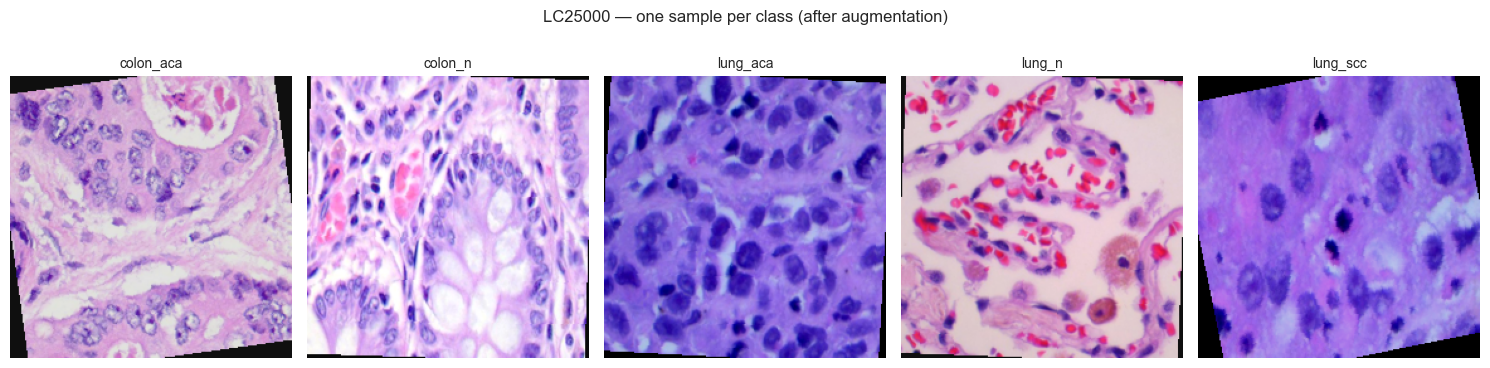

In [12]:
def denormalize(t):
    # Reverse ImageNet normalization for display
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
shown = set()
for img, label in train_dataset:
    if label in shown:
        continue
    shown.add(label)
    ax = axes[label]
    ax.imshow(denormalize(img).permute(1, 2, 0).numpy())
    ax.set_title(CLASS_NAMES[label], fontsize=10)
    ax.axis("off")
    if len(shown) == NUM_CLASSES:
        break
plt.suptitle("LC25000 — one sample per class (after augmentation)", y=1.05)
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "sample_images.png", dpi=200, bbox_inches="tight")
plt.show()

---
# 🛠️ Section 4: Common Training & Evaluation Utilities

These functions are used by **every** model, ensuring identical training and evaluation logic. This is the second pillar of fair comparison.


### 4.1 Parameter counter

In [13]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

### 4.2 Universal training function (with resume support)

Includes:
- AdamW optimizer + StepLR scheduler
- Best-model checkpointing (by validation accuracy)
- Per-epoch progress with tqdm
- Training history dictionary
- **Resume support**: writes a `local scratch` checkpoint each time val improves (fast),
  then copies the final best weights + history to Google Drive at the end of training.
  If `{model_name}_best.pth` already exists on Drive, training is **skipped entirely**
  and the saved weights are loaded — so a Colab disconnect doesn't waste finished work.

In [14]:
def _drive_paths(model_name):
    return (
        OUT_DIR / "models"  / f"{model_name}_best.pth",
        OUT_DIR / "metrics" / f"{model_name}_history.json",
    )

def _local_paths(model_name):
    return LOCAL_SCRATCH / "models" / f"{model_name}_best.pth"

def _copy_to_drive(local_path, drive_path):
    import shutil
    # On local execution, LOCAL_SCRATCH == OUT_DIR so local==drive — skip copying to self
    if Path(local_path).resolve() == Path(drive_path).resolve():
        return
    drive_path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(local_path, drive_path)


def train_one_model(model, model_name, train_loader, val_loader,
                    epochs=EPOCHS, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY):
    drive_weights, drive_history = _drive_paths(model_name)

    # ---- RESUME SHORT-CIRCUIT ----
    if (not FORCE_RETRAIN) and drive_weights.exists() and drive_history.exists():
        print(f"\n{'='*70}\n⏭️  {model_name} — already trained, loading from Drive\n{'='*70}")
        model.load_state_dict(torch.load(drive_weights, map_location=device, weights_only=True))
        model = model.to(device)
        with open(drive_history) as f:
            history = json.load(f)
        print(f"  best_val_acc = {history.get('best_val_acc', 0):.4f}")
        return model, history

    # ---- FRESH TRAINING ----
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    # Only optimize parameters that require grad (handles frozen backbones automatically)
    optimizer = optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr, weight_decay=weight_decay
    )
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

    history = {'train_loss': [], 'train_acc': [],
               'val_loss':   [], 'val_acc':   [],
               'epoch_time': []}

    best_val_acc = 0.0
    best_state = None
    local_save = _local_paths(model_name)

    print(f"\n{'='*70}\n🚂 Training {model_name}\n{'='*70}")
    total_p, trainable_p = count_parameters(model)
    print(f"  Total parameters:     {total_p:,}")
    print(f"  Trainable parameters: {trainable_p:,}")

    for epoch in range(epochs):
        t0 = time.time()
        # ---- TRAIN ----
        model.train()
        run_loss, run_correct, n = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f"  Epoch {epoch+1}/{epochs} [train]", leave=False)
        for x, y in pbar:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            run_loss   += loss.item() * x.size(0)
            run_correct += (out.argmax(1) == y).sum().item()
            n          += x.size(0)
            pbar.set_postfix(loss=run_loss/n, acc=run_correct/n)
        train_loss, train_acc = run_loss/n, run_correct/n

        # ---- VAL ----
        model.eval()
        v_loss, v_correct, v_n = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
                out = model(x)
                loss = criterion(out, y)
                v_loss   += loss.item() * x.size(0)
                v_correct += (out.argmax(1) == y).sum().item()
                v_n      += x.size(0)
        val_loss, val_acc = v_loss/v_n, v_correct/v_n

        scheduler.step()
        elapsed = time.time() - t0

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['epoch_time'].append(elapsed)

        print(f"  Epoch {epoch+1:2d}/{epochs} | "
              f"train_loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} acc={val_acc:.4f} | "
              f"time={elapsed:.1f}s")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = deepcopy(model.state_dict())
            torch.save(best_state, local_save)        # fast local save during training

    # ---- FINALIZE ----
    if best_state is not None:
        model.load_state_dict(best_state)

    history['best_val_acc']      = best_val_acc
    history['total_params']      = total_p
    history['trainable_params']  = trainable_p

    # Persist to Drive (one-shot at the end → avoids slow per-epoch Drive writes)
    print(f"  💾 Saving to Drive → {drive_weights.name} ...", end="", flush=True)
    _copy_to_drive(local_save, drive_weights)
    with open(drive_history, "w") as f:
        json.dump(history, f, indent=2)
    print(" done")

    print(f"  ✅ Best val_acc = {best_val_acc:.4f}")
    return model, history

### 4.3 Universal evaluation function — produces all metrics

In [15]:
def evaluate_model(model, loader, model_name):
    model = model.to(device).eval()
    all_preds, all_labels, all_probs = [], [], []
    inf_times = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc=f"  Evaluating {model_name}", leave=False):
            x = x.to(device, non_blocking=True)
            t0 = time.time()
            logits = model(x)
            torch.cuda.synchronize() if device.type == "cuda" else None
            inf_times.append((time.time() - t0) / x.size(0))   # per-sample
            probs = F.softmax(logits, dim=1)
            preds = logits.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.numpy())
            all_probs.append(probs.cpu().numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.concatenate(all_probs, axis=0)

    # Overall metrics
    acc        = accuracy_score(y_true, y_pred)
    p_macro    = precision_score(y_true, y_pred, average='macro', zero_division=0)
    r_macro    = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    p_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    r_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_weighted= f1_score(y_true, y_pred, average='weighted', zero_division=0)
    kappa      = cohen_kappa_score(y_true, y_pred)
    mcc        = matthews_corrcoef(y_true, y_pred)

    # Per-class metrics
    p_class, r_class, f1_class, support = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(NUM_CLASSES)), zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

    metrics = {
        'model_name': model_name,
        'accuracy':   float(acc),
        'precision_macro':    float(p_macro),
        'recall_macro':       float(r_macro),
        'f1_macro':           float(f1_macro),
        'precision_weighted': float(p_weighted),
        'recall_weighted':    float(r_weighted),
        'f1_weighted':        float(f1_weighted),
        'cohen_kappa':        float(kappa),
        'mcc':                float(mcc),
        'mean_inference_ms_per_sample': float(np.mean(inf_times) * 1000),
        'per_class': {
            CLASS_NAMES[i]: {
                'precision': float(p_class[i]),
                'recall':    float(r_class[i]),
                'f1':        float(f1_class[i]),
                'support':   int(support[i])
            } for i in range(NUM_CLASSES)
        },
        'confusion_matrix': cm.tolist(),
        'y_true': y_true.tolist(),
        'y_pred': y_pred.tolist(),
        'y_prob': y_prob.tolist(),
    }
    # save to disk
    with open(OUT_DIR / "metrics" / f"{model_name}_metrics.json", "w") as f:
        # don't save y_prob to JSON (too large) — save separately
        save = {k: v for k, v in metrics.items() if k != 'y_prob'}
        json.dump(save, f, indent=2)
    np.save(OUT_DIR / "metrics" / f"{model_name}_yprob.npy", y_prob)
    return metrics

### 4.4 Plotting helpers

In [16]:
def plot_training_history(history, model_name, ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(history['train_loss'], label='train', marker='o')
    ax[0].plot(history['val_loss'],   label='val',   marker='s')
    ax[0].set_title(f"{model_name} — Loss")
    ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss"); ax[0].legend()
    ax[1].plot(history['train_acc'], label='train', marker='o')
    ax[1].plot(history['val_acc'],   label='val',   marker='s')
    ax[1].set_title(f"{model_name} — Accuracy")
    ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Accuracy"); ax[1].legend()

def plot_confusion_matrix(cm, class_names, model_name, ax=None, normalize=False):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    if normalize:
        cm_show = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        fmt = ".2f"
    else:
        cm_show = cm
        fmt = "d"
    sns.heatmap(cm_show, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax,
                cbar=True, square=True)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"{model_name}{' (normalized)' if normalize else ''}")

---
# 🏗️ Section 5: Model Architectures

Each model is built by a small factory function that returns a fresh `nn.Module`. This way we can re-train any model from scratch without state leakage.

**Strategies:**
- **VGG16, ResNet-50, FSPAN-Y**: backbone frozen, only the classifier head is trained → fast, low-overfit, mirrors your original `vgg-cancer-detection.ipynb` and `resnet-cancer-detection.ipynb` exactly.
- **MobileNetV3, ViT-Base, ConvNeXt-Tiny**: full fine-tune → mirrors your `transferlearning-mobilenetv3.ipynb` and `cancer-detection.ipynb`.


### 5.1 VGG16 (frozen features)

In [17]:
def build_vgg16(num_classes=NUM_CLASSES):
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    for p in model.parameters():
        p.requires_grad = False
    in_f = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(in_f, num_classes)
    return model

### 5.2 ResNet-50 (frozen features)

In [18]:
def build_resnet50(num_classes=NUM_CLASSES):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    for p in model.parameters():
        p.requires_grad = False
    in_f = model.fc.in_features
    model.fc = nn.Linear(in_f, num_classes)
    return model

### 5.3 MobileNetV3-Small (fine-tune)

In [19]:
def build_mobilenetv3(num_classes=NUM_CLASSES):
    return timm.create_model('mobilenetv3_small_100', pretrained=True, num_classes=num_classes)

### 5.4 Vision Transformer (ViT-Base/16, fine-tune)

In [20]:
def build_vit(num_classes=NUM_CLASSES):
    return timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=num_classes)

### 5.5 ConvNeXt-Tiny (fine-tune)

In [21]:
def build_convnext(num_classes=NUM_CLASSES):
    return timm.create_model('convnext_tiny', pretrained=True, num_classes=num_classes)

### 5.6 FSPAN-Y — ConvNeXt-Tiny + Attention + Y-Block (custom)

This is a PyTorch reimplementation of your `fspan-y-pretrained-convnexttiny-for-lung.ipynb` novel architecture. The original paper-style idea:
1. Extract feature maps with a frozen ConvNeXt-Tiny backbone.
2. Apply a learned **spatial attention mask** over the feature map (so the model can emphasize informative regions).
3. Pass the attended features through three **Y-Blocks** (dilated dual-path conv blocks with residual addition) that progressively reduce channel count.
4. Global average pool + dropout + linear classifier.

In [22]:
class YBlock(nn.Module):
    # Dilated dual-path block with residual addition.
    def __init__(self, in_ch, out_ch, dilation=2):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=dilation, dilation=dilation)
        self.bn2   = nn.BatchNorm2d(out_ch)
    def forward(self, x):
        a = F.relu(self.bn1(self.conv1(x)), inplace=True)
        b = F.relu(self.bn2(self.conv2(a)), inplace=True)
        return F.relu(a + b, inplace=True)


class FSPAN_Y(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        # Frozen ConvNeXt-Tiny feature extractor (last stage only)
        self.backbone = timm.create_model(
            'convnext_tiny', pretrained=True, features_only=True, out_indices=(3,)
        )
        for p in self.backbone.parameters():
            p.requires_grad = False
        feat_ch = self.backbone.feature_info.channels()[-1]   # typically 768

        # 1x1 bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(feat_ch, 512, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
        )
        # Spatial attention mask -> (B,1,H,W) in [0,1]
        self.attention = nn.Sequential(
            nn.Conv2d(512, 64, 1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 16, 1),  nn.ReLU(inplace=True),
            nn.Conv2d(16, 1, 1),   nn.Sigmoid(),
        )
        # Stack of Y-Blocks reducing channels
        self.y1 = YBlock(512, 256, dilation=2)
        self.y2 = YBlock(256, 128, dilation=2)
        self.y3 = YBlock(128, 64,  dilation=2)
        # Classifier
        self.gap     = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.5)
        self.fc      = nn.Linear(64, num_classes)

    def forward(self, x):
        f = self.backbone(x)[0]            # (B, 768, H, W)
        f = self.bottleneck(f)             # (B, 512, H, W)
        attn = self.attention(f)           # (B, 1, H, W)
        f = f * attn                       # spatial attention applied
        f = self.y1(f)
        f = self.y2(f)
        f = self.y3(f)
        f = self.gap(f).flatten(1)         # (B, 64)
        f = self.dropout(f)
        return self.fc(f)


def build_fspan_y(num_classes=NUM_CLASSES):
    return FSPAN_Y(num_classes=num_classes)

### 5.7 EfficientNet-B0 (fine-tune)

In [23]:
def build_efficientnet_b0(num_classes=NUM_CLASSES):
    return timm.create_model('efficientnet_b0', pretrained=True, num_classes=num_classes)

### 5.8 EfficientNet-B3 (fine-tune)

In [24]:
def build_efficientnet_b3(num_classes=NUM_CLASSES):
    return timm.create_model('tf_efficientnet_b3', pretrained=True, num_classes=num_classes)

### 5.9 Swin Transformer-Tiny (fine-tune)

In [25]:
def build_swin_tiny(num_classes=NUM_CLASSES):
    return timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=num_classes)

### 5.10 DenseNet-121 (fine-tune)

In [26]:
def build_densenet121(num_classes=NUM_CLASSES):
    return timm.create_model('densenet121', pretrained=True, num_classes=num_classes)

### 5.11 🆕 DPCT-Net — Dual-Path CNN-Transformer Network with Gated Fusion (NOVEL)

**Motivation for your paper:**
> *Histopathology classification benefits from both **local texture features** (cell-level nuclei patterns) — which CNNs capture well — and **global tissue context** — which transformers capture well. We propose **DPCT-Net**, which combines a frozen ConvNeXt-Tiny CNN stream and a frozen Swin-Tiny transformer stream via a learned cross-attention module and an adaptive per-sample gating mechanism that decides how much each stream contributes to the final classification.*

**Architecture:**
```
Image (3×224×224)
   ┌──────────────┴──────────────┐
ConvNeXt-Tiny (frozen)    Swin-Tiny (frozen)
        ↓                          ↓
   f_cnn (768)               f_swin (768)
        ↓                          ↓
   Project to 256          Project to 256
        ↓                          ↓
        └───── Cross-Attention ────┘
            (each stream attends
               to the other)
                    ↓
              Gating MLP
       (per-sample weights α₁, α₂)
                    ↓
        f_fused = α₁·z_cnn + α₂·z_swin
                    ↓
            Dropout + Linear → 5 classes
```

**Publishable novelty:** per-sample adaptive gating between CNN and Transformer streams is uncommon in published LC25000 work. You can visualize gate weights per sample for an interpretability figure ("on `lung_scc` images, the model relies 70% on the CNN stream").

In [27]:
class DPCT_Net(nn.Module):
    # Dual-Path CNN-Transformer Network with Gated Fusion.
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        # Two frozen pretrained backbones — CNN stream and Transformer stream
        self.cnn = timm.create_model('convnext_tiny', pretrained=True,
                                     num_classes=0, global_pool='avg')
        self.tfm = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True,
                                     num_classes=0, global_pool='avg')
        for p in self.cnn.parameters(): p.requires_grad = False
        for p in self.tfm.parameters(): p.requires_grad = False
        cnn_dim = self.cnn.num_features    # 768
        tfm_dim = self.tfm.num_features    # 768
        d = 256

        # Project each stream into a common 256-d latent space
        self.proj_cnn = nn.Sequential(nn.Linear(cnn_dim, d), nn.GELU(), nn.LayerNorm(d))
        self.proj_tfm = nn.Sequential(nn.Linear(tfm_dim, d), nn.GELU(), nn.LayerNorm(d))

        # Cross-attention: 2-token sequence (cnn, tfm), each attends to the other
        self.cross_attn = nn.MultiheadAttention(d, num_heads=4, batch_first=True)

        # Gating MLP — produces per-sample softmax weights for the two streams
        self.gate = nn.Sequential(
            nn.Linear(d * 2, d), nn.GELU(),
            nn.Linear(d, 2), nn.Softmax(dim=-1)
        )

        # Classifier head
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(d, num_classes))

    def forward(self, x, return_gate=False):
        # Frozen backbones — no gradients, saves memory
        with torch.no_grad():
            f_cnn = self.cnn(x)              # (B, 768)
            f_tfm = self.tfm(x)              # (B, 768)
        z_cnn = self.proj_cnn(f_cnn)         # (B, 256)
        z_tfm = self.proj_tfm(f_tfm)         # (B, 256)

        # Cross-attention on 2-token sequence
        seq = torch.stack([z_cnn, z_tfm], dim=1)         # (B, 2, 256)
        attn_out, _ = self.cross_attn(seq, seq, seq)     # (B, 2, 256)

        # Per-sample gating
        gate = self.gate(torch.cat([z_cnn, z_tfm], dim=-1))   # (B, 2)
        f_fused = gate[:, 0:1] * attn_out[:, 0] + gate[:, 1:2] * attn_out[:, 1]

        if return_gate:
            return self.classifier(f_fused), gate
        return self.classifier(f_fused)


def build_dpct(num_classes=NUM_CLASSES):
    return DPCT_Net(num_classes=num_classes)

### 5.12 🆕 MSCA-Net — Multi-Scale Cascade Attention Network (NOVEL)

**Motivation for your paper:**
> *Histopathology images contain diagnostic information at **multiple scales** — from individual cell nuclei (fine-grained, captured in shallow features) to tissue-level architecture (coarse-grained, captured in deep features). We propose **MSCA-Net**, which extracts features from three stages of a frozen ConvNeXt-Tiny backbone and applies **top-down cascade attention**: deeper-stage features generate spatial attention maps that guide where shallower stages should focus, before all scales are fused for classification.*

**Architecture:**
```
Image (3×224×224)
       ↓
ConvNeXt-Tiny (frozen, features only)
       ├──── Stage 2  (192ch, 28×28)
       ├──── Stage 3  (384ch, 14×14)
       └──── Stage 4  (768ch,  7×7)

   Project each to 256ch
       ↓
   Apply SE channel attention per scale
       ↓
   Top-down cascade:
       Stage 4 → generates spatial attention →
       Stage 3 weighted by it → generates spatial attention →
       Stage 2 weighted by it
       ↓
   GAP each, concatenate → (768)
       ↓
   Scale fusion MLP → (256)
       ↓
   Dropout + Linear → 5 classes
```

**Publishable novelty:** top-down cascade attention where deeper features explicitly modulate shallower ones via interpolated spatial maps is a specific design choice that distinguishes MSCA-Net from FPN-style multi-scale fusion (which only concatenates) and from FSPAN-Y (single-scale).

In [28]:
class MSCA_Net(nn.Module):
    # Multi-Scale Cascade Attention Network.
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        # Frozen backbone, features only from 3 stages
        self.backbone = timm.create_model(
            'convnext_tiny', pretrained=True,
            features_only=True, out_indices=(1, 2, 3)
        )
        for p in self.backbone.parameters(): p.requires_grad = False
        channels = self.backbone.feature_info.channels()  # [192, 384, 768]
        d = 256

        # Project each scale to common channel dim
        self.proj = nn.ModuleList([
            nn.Sequential(nn.Conv2d(c, d, 1), nn.BatchNorm2d(d), nn.GELU())
            for c in channels
        ])
        # Channel attention (SE) per scale
        self.ca = nn.ModuleList([
            nn.Sequential(
                nn.AdaptiveAvgPool2d(1),
                nn.Conv2d(d, d // 8, 1), nn.ReLU(inplace=True),
                nn.Conv2d(d // 8, d, 1), nn.Sigmoid()
            ) for _ in channels
        ])
        # Spatial attention generator at each scale (used to guide shallower scale)
        self.spatial_attn = nn.ModuleList([
            nn.Sequential(nn.Conv2d(d, 1, 1), nn.Sigmoid())
            for _ in channels
        ])
        # Multi-scale fusion
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.scale_fusion = nn.Sequential(
            nn.Linear(d * len(channels), d), nn.GELU(), nn.LayerNorm(d)
        )
        # Classifier
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(d, num_classes))

    def forward(self, x):
        with torch.no_grad():
            feats = self.backbone(x)              # list of 3 feature maps
        projected = [proj(f) for proj, f in zip(self.proj, feats)]

        # Top-down cascade attention
        refined = [None] * len(projected)
        # Deepest level: channel attention only
        refined[-1] = projected[-1] * self.ca[-1](projected[-1])
        # Cascade: deeper attention guides shallower
        for i in range(len(projected) - 2, -1, -1):
            attn_deep = self.spatial_attn[i + 1](refined[i + 1])
            attn_deep = F.interpolate(attn_deep, size=projected[i].shape[2:],
                                      mode='bilinear', align_corners=False)
            refined[i] = projected[i] * self.ca[i](projected[i]) * attn_deep

        # Pool + concat across scales
        pooled = [self.gap(r).flatten(1) for r in refined]
        fused = torch.cat(pooled, dim=1)
        z = self.scale_fusion(fused)
        return self.classifier(z)


def build_msca(num_classes=NUM_CLASSES):
    return MSCA_Net(num_classes=num_classes)

### 5.13 Model registry — all 12 models

In [29]:
# ORDER MATTERS — train smaller/faster models first, so a disconnect
# loses the least work. Already-trained models from a previous run are skipped automatically.
MODELS = {
    # --- already trained in your previous run (will be skipped) ---
    "VGG16":          build_vgg16,
    "ResNet50":       build_resnet50,
    "MobileNetV3":    build_mobilenetv3,
    "ViT_Base":       build_vit,
    "ConvNeXt_Tiny":  build_convnext,
    "FSPAN_Y":        build_fspan_y,
    # --- new in this run (smallest/fastest first) ---
    "EfficientNet_B0": build_efficientnet_b0,
    "DenseNet121":     build_densenet121,
    "MSCA_Net":        build_msca,           # 🆕 novel
    "EfficientNet_B3": build_efficientnet_b3,
    "Swin_Tiny":       build_swin_tiny,
    "DPCT_Net":        build_dpct,           # 🆕 novel
}
print(f"Registered models: {list(MODELS.keys())}")
print(f"Total: {len(MODELS)} models (including 2 novel custom hybrids)")

Registered models: ['VGG16', 'ResNet50', 'MobileNetV3', 'ViT_Base', 'ConvNeXt_Tiny', 'FSPAN_Y', 'EfficientNet_B0', 'DenseNet121', 'MSCA_Net', 'EfficientNet_B3', 'Swin_Tiny', 'DPCT_Net']
Total: 12 models (including 2 novel custom hybrids)


---
# 🚂 Section 6: Train All Models (resume-aware)

This loop trains every model in `MODELS` with **identical** hyperparameters and **identical** data loaders. Best weights (by validation accuracy) and metrics are saved to **Google Drive** (`OUT_DIR`) so they survive Colab disconnects.

### How resume works

For each model, the loop checks Drive for three files:

| File | Meaning |
|---|---|
| `models/{name}_best.pth` | Trained weights |
| `metrics/{name}_history.json` | Training curve data |
| `metrics/{name}_metrics.json` | Final test-set metrics |

Three branches:
1. **All three exist** → load everything from Drive, skip both training and evaluation. ⏭️
2. **Weights + history exist, metrics don't** → load weights, run evaluation only. ⏪
3. **Nothing on Drive** → train from scratch, then evaluate. 🚂

So if your runtime dies after training 3 of 6 models, just re-run from the top: those 3 models are skipped, the remaining 3 are trained.

**To force a full retrain**, set `FORCE_RETRAIN = True` in Section 3.1.

**Time estimates per model on T4:**
- VGG16, ResNet-50: ~5–8 min (only training the classifier head)
- MobileNetV3:      ~6–10 min (tiny model, full fine-tune)
- ConvNeXt-Tiny:    ~12–18 min
- ViT-Base:         ~15–25 min (largest)
- FSPAN-Y:          ~8–12 min (frozen backbone + small head)

**Total: ~60–90 min on a Colab T4 GPU at 10 epochs** (only on the first run; subsequent runs skip completed models).


### 6.1 Resume status preview — what will be skipped / trained

In [30]:
# Show the user what will happen before any training starts
print(f"FORCE_RETRAIN = {FORCE_RETRAIN}")
print(f"FORCE_REEVAL  = {FORCE_REEVAL}\n")
print(f"{'Model':<14s}  {'Weights':<8s}  {'History':<8s}  {'Metrics':<8s}  → Action")
print("-" * 70)
for name in MODELS.keys():
    w = (OUT_DIR / "models"  / f"{name}_best.pth").exists()
    h = (OUT_DIR / "metrics" / f"{name}_history.json").exists()
    m = (OUT_DIR / "metrics" / f"{name}_metrics.json").exists()
    if FORCE_RETRAIN:
        action = "🚂 TRAIN + EVAL (forced)"
    elif w and h and m and not FORCE_REEVAL:
        action = "⏭️  SKIP (all done)"
    elif w and h:
        action = "⏪ LOAD weights, EVAL only"
    else:
        action = "🚂 TRAIN + EVAL (fresh)"
    print(f"  {name:<12s}  {'✓' if w else '·':<8s}  {'✓' if h else '·':<8s}  {'✓' if m else '·':<8s}  → {action}")

FORCE_RETRAIN = False
FORCE_REEVAL  = False

Model           Weights   History   Metrics   → Action
----------------------------------------------------------------------
  VGG16         ✓         ✓         ✓         → ⏭️  SKIP (all done)
  ResNet50      ✓         ✓         ✓         → ⏭️  SKIP (all done)
  MobileNetV3   ✓         ✓         ✓         → ⏭️  SKIP (all done)
  ViT_Base      ✓         ✓         ✓         → ⏭️  SKIP (all done)
  ConvNeXt_Tiny  ✓         ✓         ✓         → ⏭️  SKIP (all done)
  FSPAN_Y       ✓         ✓         ✓         → ⏭️  SKIP (all done)
  EfficientNet_B0  ✓         ✓         ✓         → ⏭️  SKIP (all done)
  DenseNet121   ✓         ✓         ✓         → ⏭️  SKIP (all done)
  MSCA_Net      ✓         ✓         ✓         → ⏭️  SKIP (all done)
  EfficientNet_B3  ✓         ✓         ✓         → ⏭️  SKIP (all done)
  Swin_Tiny     ✓         ✓         ✓         → ⏭️  SKIP (all done)
  DPCT_Net      ✓         ✓         ✓         → ⏭️  SKIP (all done)


### 6.2 Train + evaluate all models

In [31]:
# ---- Train every model (resume-aware) ----
all_histories = {}
all_metrics   = {}

for name, build_fn in MODELS.items():
    print("\n" + "█" * 70)
    print(f"█ {name}")
    print("█" * 70)

    drive_weights = OUT_DIR / "models"  / f"{name}_best.pth"
    drive_history = OUT_DIR / "metrics" / f"{name}_history.json"
    drive_metrics = OUT_DIR / "metrics" / f"{name}_metrics.json"
    drive_yprob   = OUT_DIR / "metrics" / f"{name}_yprob.npy"

    # ============== BRANCH 1: fully done — skip both train and eval ==============
    if (not FORCE_RETRAIN and not FORCE_REEVAL
            and drive_weights.exists() and drive_history.exists()
            and drive_metrics.exists() and drive_yprob.exists()):
        print(f"⏭️  {name}: complete — loading from Drive")
        with open(drive_history) as f:
            all_histories[name] = json.load(f)
        with open(drive_metrics) as f:
            all_metrics[name] = json.load(f)
        print(f"  test_acc={all_metrics[name]['accuracy']:.4f} | "
              f"f1_macro={all_metrics[name]['f1_macro']:.4f} | "
              f"kappa={all_metrics[name]['cohen_kappa']:.4f}")
        continue

    # ============== BRANCH 2 & 3: build fresh model ==============
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    model = build_fn()

    # train_one_model itself short-circuits if drive_weights + drive_history exist
    # (so this handles BRANCH 2 = weights/history exist, eval missing)
    trained_model, hist = train_one_model(
        model, name, train_loader, val_loader,
        epochs=EPOCHS, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
    )
    all_histories[name] = hist

    print(f"\n📊 Evaluating {name} on TEST set...")
    metrics = evaluate_model(trained_model, test_loader, name)
    all_metrics[name] = metrics
    print(f"  test_acc={metrics['accuracy']:.4f} | "
          f"f1_macro={metrics['f1_macro']:.4f} | "
          f"kappa={metrics['cohen_kappa']:.4f}")

    # free GPU memory before next model
    del trained_model, model
    torch.cuda.empty_cache() if device.type == "cuda" else None

print("\n" + "█" * 70)
print("✅ All models trained and evaluated.")
print("█" * 70)


██████████████████████████████████████████████████████████████████████
█ VGG16
██████████████████████████████████████████████████████████████████████
⏭️  VGG16: complete — loading from Drive
  test_acc=0.9276 | f1_macro=0.9271 | kappa=0.9095

██████████████████████████████████████████████████████████████████████
█ ResNet50
██████████████████████████████████████████████████████████████████████
⏭️  ResNet50: complete — loading from Drive
  test_acc=0.9636 | f1_macro=0.9636 | kappa=0.9545

██████████████████████████████████████████████████████████████████████
█ MobileNetV3
██████████████████████████████████████████████████████████████████████
⏭️  MobileNetV3: complete — loading from Drive
  test_acc=1.0000 | f1_macro=1.0000 | kappa=1.0000

██████████████████████████████████████████████████████████████████████
█ ViT_Base
██████████████████████████████████████████████████████████████████████
⏭️  ViT_Base: complete — loading from Drive
  test_acc=1.0000 | f1_macro=1.0000 | kappa=1.0000

███

---
# 📊 Section 7: Comprehensive Analysis & Comparison

This is the heart of your research paper. Each subsection produces a publication-ready figure or table.


### 7.1 Master metrics table

In [32]:
rows = []
for name, m in all_metrics.items():
    rows.append({
        "Model":                name,
        "Test Accuracy":        m['accuracy'],
        "Precision (macro)":    m['precision_macro'],
        "Recall (macro)":       m['recall_macro'],
        "F1 (macro)":           m['f1_macro'],
        "Precision (weighted)": m['precision_weighted'],
        "Recall (weighted)":    m['recall_weighted'],
        "F1 (weighted)":        m['f1_weighted'],
        "Cohen Kappa":          m['cohen_kappa'],
        "MCC":                  m['mcc'],
        "Inference (ms/img)":   m['mean_inference_ms_per_sample'],
        "Total Params":         all_histories[name]['total_params'],
        "Trainable Params":     all_histories[name]['trainable_params'],
        "Best Val Acc":         all_histories[name]['best_val_acc'],
    })

results_df = pd.DataFrame(rows).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
results_df.to_csv(OUT_DIR / "metrics" / "results_summary.csv", index=False)

# Pretty print
display(results_df.style.format({
    "Test Accuracy":        "{:.4f}",
    "Precision (macro)":    "{:.4f}",
    "Recall (macro)":       "{:.4f}",
    "F1 (macro)":           "{:.4f}",
    "Precision (weighted)": "{:.4f}",
    "Recall (weighted)":    "{:.4f}",
    "F1 (weighted)":        "{:.4f}",
    "Cohen Kappa":          "{:.4f}",
    "MCC":                  "{:.4f}",
    "Inference (ms/img)":   "{:.2f}",
    "Best Val Acc":         "{:.4f}",
    "Total Params":         "{:,}",
    "Trainable Params":     "{:,}",
}).background_gradient(subset=["Test Accuracy", "F1 (macro)", "Cohen Kappa"], cmap="Greens"))

,Model,Test Accuracy,Precision (macro),Recall (macro),F1 (macro),Precision (weighted),Recall (weighted),F1 (weighted),Cohen Kappa,MCC,Inference (ms/img),Total Params,Trainable Params,Best Val Acc
0,ViT_Base,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,13.12,"85,802,501","85,802,501",0.9998
1,MobileNetV3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.22,"1,522,981","1,522,981",1.0000
2,DenseNet121,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,2.34,"6,958,981","6,958,981",1.0000
3,ConvNeXt_Tiny,0.9996,0.9996,0.9996,0.9996,0.9996,0.9996,0.9996,0.9995,0.9995,19.01,"27,823,973","27,823,973",1.0000
4,Swin_Tiny,0.9996,0.9996,0.9996,0.9996,0.9996,0.9996,0.9996,0.9995,0.9995,2.37,"27,523,199","27,523,199",1.0000
5,EfficientNet_B3,0.9992,0.9992,0.9992,0.9992,0.9992,0.9992,0.9992,0.9990,0.9990,1.84,"10,703,917","10,703,917",1.0000
6,DPCT_Net,0.9992,0.9992,0.9992,0.9992,0.9992,0.9992,0.9992,0.9990,0.9990,4.27,"56,130,529","791,047",0.9989
7,EfficientNet_B0,0.9992,0.9992,0.9992,0.9992,0.9992,0.9992,0.9992,0.9990,0.9990,1.18,"4,013,953","4,013,953",0.9998
8,FSPAN_Y,0.9984,0.9984,0.9984,0.9984,0.9984,0.9984,0.9984,0.9980,0.9980,14.55,"30,572,678","2,754,086",0.9984
9,MSCA_Net,0.9980,0.9980,0.9980,0.9980,0.9980,0.9980,0.9980,0.9975,0.9975,6.42,"28,414,408","595,816",0.9978


### 7.2 Side-by-side bar chart (overall metrics)

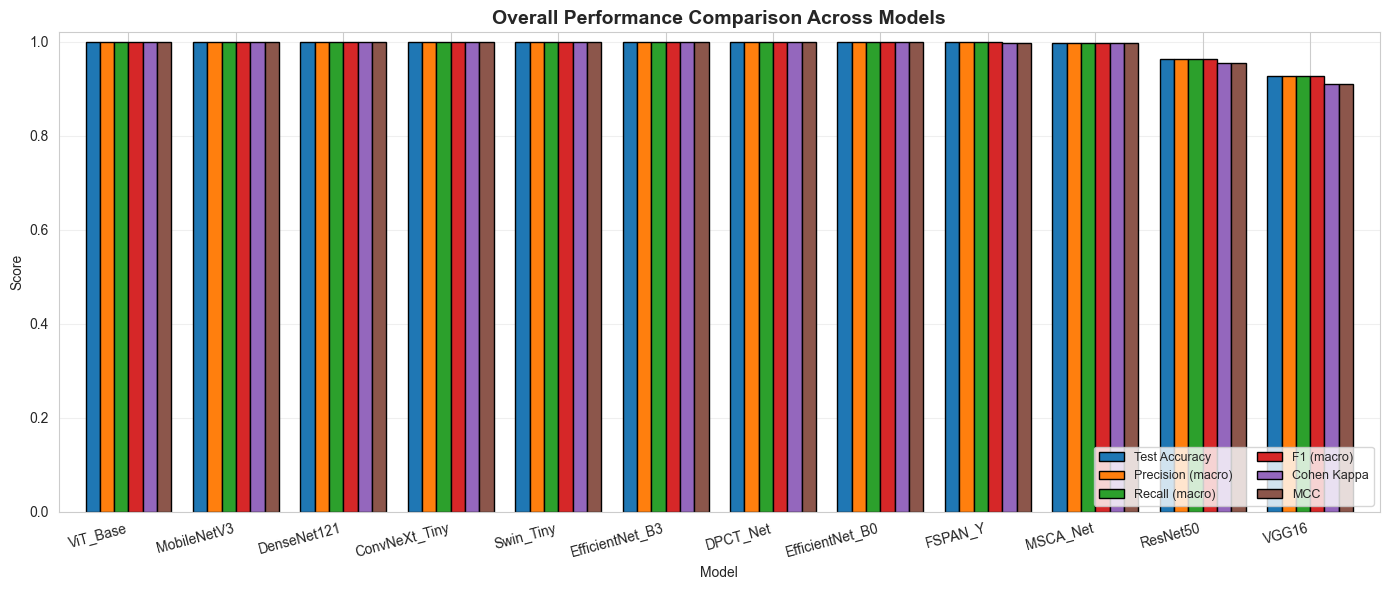

In [33]:
metrics_to_plot = ["Test Accuracy", "Precision (macro)", "Recall (macro)",
                   "F1 (macro)", "Cohen Kappa", "MCC"]
fig, ax = plt.subplots(figsize=(14, 6))
df_plot = results_df.set_index("Model")[metrics_to_plot]
df_plot.plot(kind="bar", ax=ax, width=0.8, edgecolor="black")
ax.set_title("Overall Performance Comparison Across Models", fontsize=14, fontweight="bold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.02)
ax.legend(loc="lower right", fontsize=9, ncol=2)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "overall_comparison_bar.png", dpi=300, bbox_inches="tight")
plt.savefig(OUT_DIR / "figures" / "overall_comparison_bar.pdf", bbox_inches="tight")
plt.show()

### 7.3 Confusion matrices grid (counts and normalized)

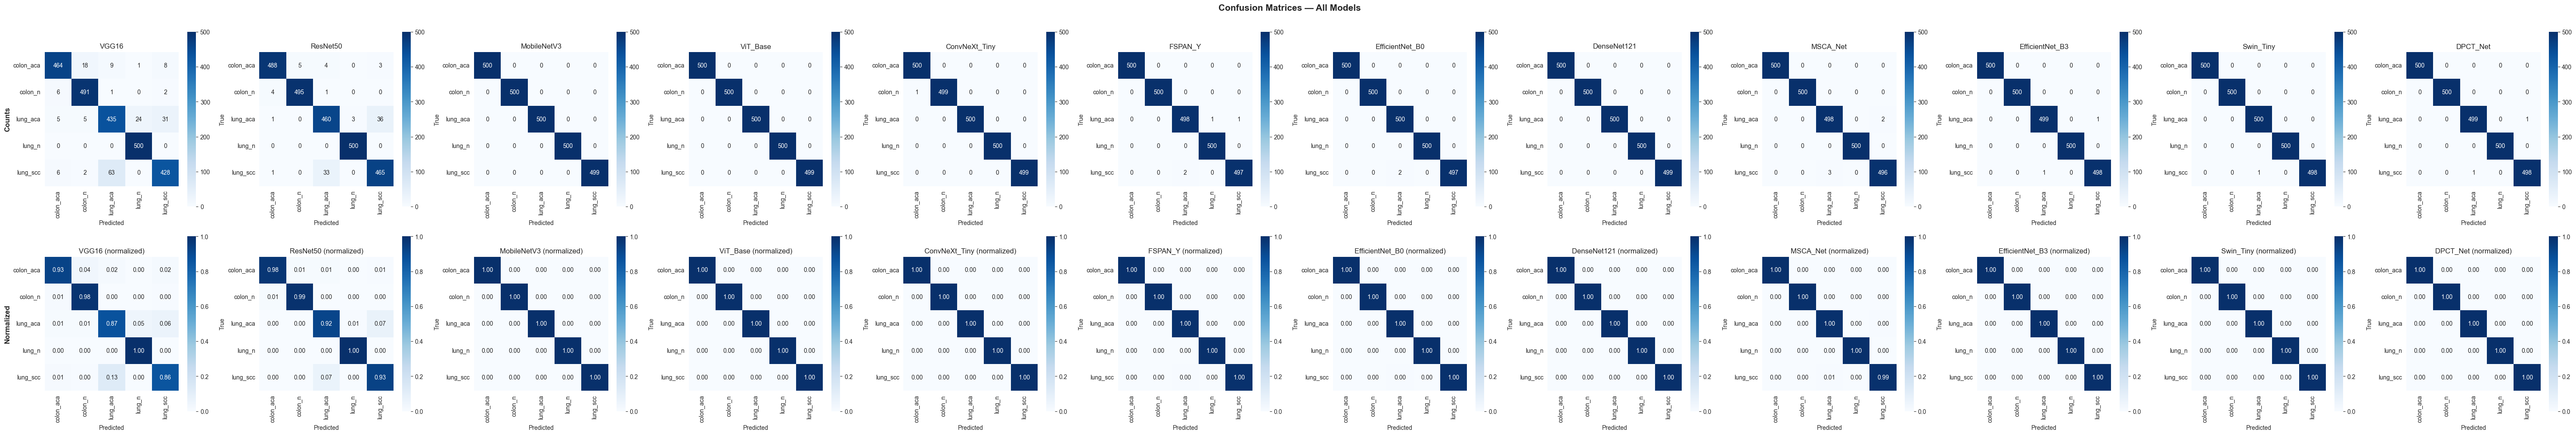

In [34]:
n_models = len(all_metrics)
fig, axes = plt.subplots(2, n_models, figsize=(5*n_models, 10))
if n_models == 1:
    axes = axes.reshape(2, 1)

for i, (name, m) in enumerate(all_metrics.items()):
    cm = np.array(m['confusion_matrix'])
    plot_confusion_matrix(cm, CLASS_NAMES, name, ax=axes[0, i], normalize=False)
    plot_confusion_matrix(cm, CLASS_NAMES, name, ax=axes[1, i], normalize=True)

axes[0, 0].set_ylabel("Counts", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("Normalized", fontsize=12, fontweight="bold")
plt.suptitle("Confusion Matrices — All Models", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "confusion_matrices_grid.png", dpi=300, bbox_inches="tight")
plt.savefig(OUT_DIR / "figures" / "confusion_matrices_grid.pdf", bbox_inches="tight")
plt.show()

### 7.4 Per-class metrics heatmaps

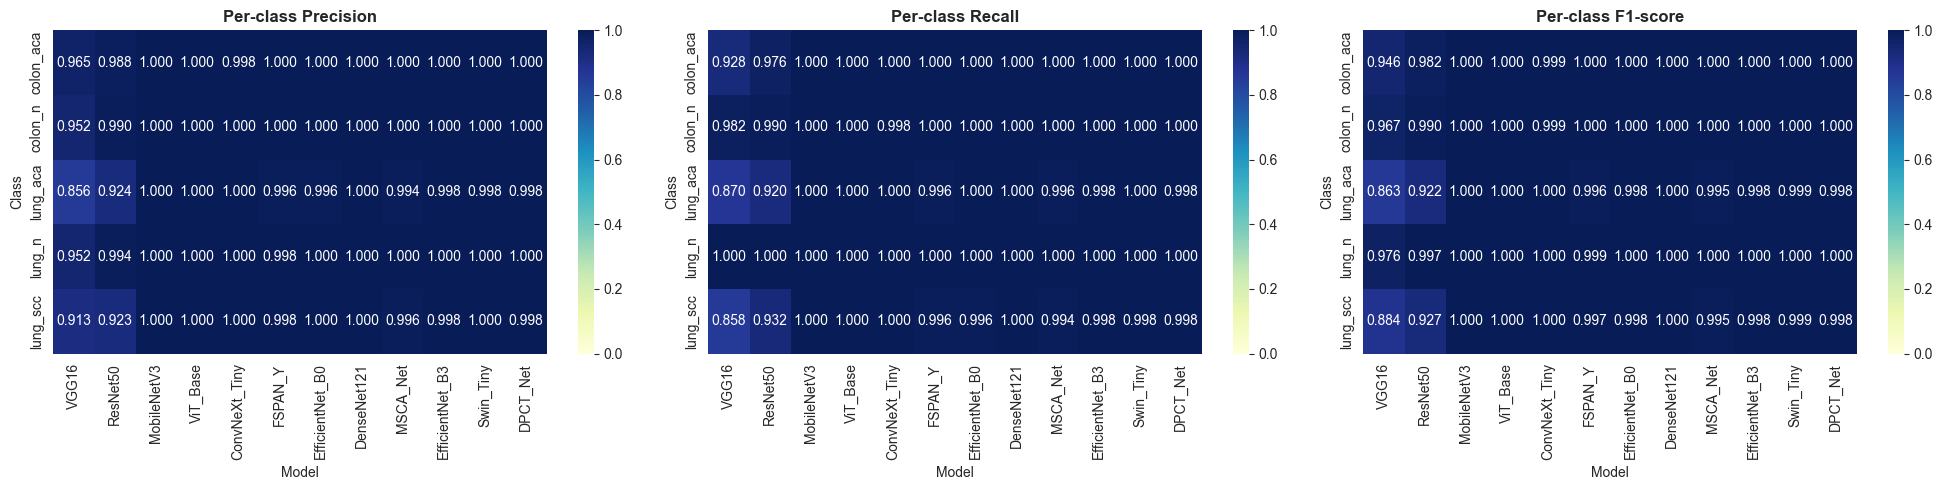

In [35]:
def per_class_df(metric_key):
    data = {}
    for name, m in all_metrics.items():
        data[name] = [m['per_class'][cn][metric_key] for cn in CLASS_NAMES]
    return pd.DataFrame(data, index=CLASS_NAMES)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, key, title in zip(axes, ['precision', 'recall', 'f1'],
                          ['Precision', 'Recall', 'F1-score']):
    df_pc = per_class_df(key)
    sns.heatmap(df_pc, annot=True, fmt=".3f", cmap="YlGnBu",
                vmin=0, vmax=1, cbar=True, ax=ax)
    ax.set_title(f"Per-class {title}", fontweight="bold")
    ax.set_xlabel("Model"); ax.set_ylabel("Class")
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "per_class_heatmaps.png", dpi=300, bbox_inches="tight")
plt.savefig(OUT_DIR / "figures" / "per_class_heatmaps.pdf", bbox_inches="tight")
plt.show()

### 7.5 Training-curve comparison

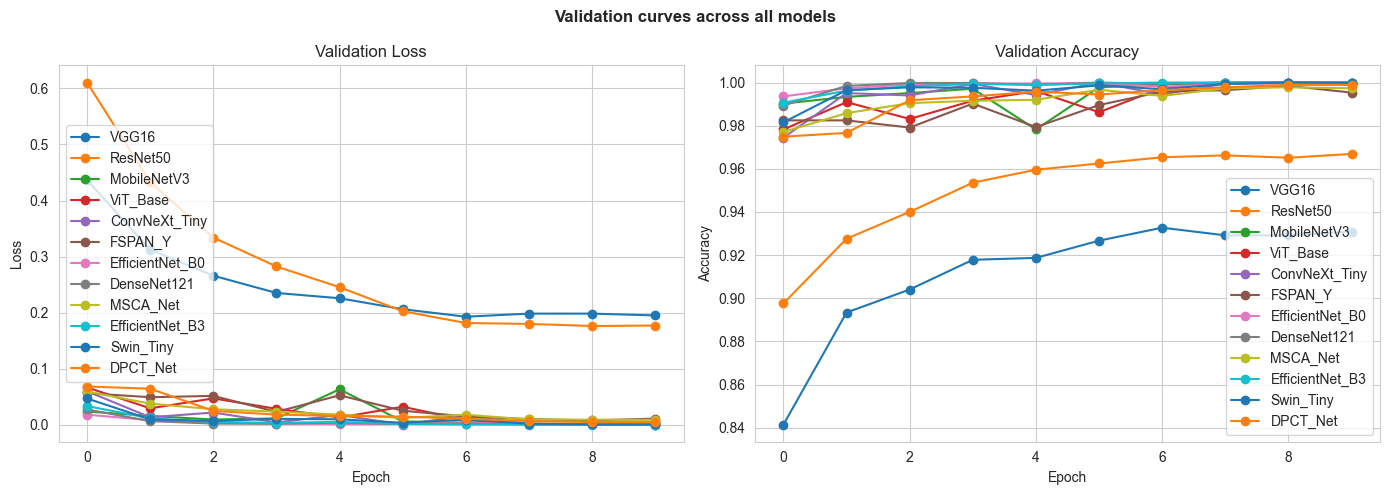

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, h in all_histories.items():
    axes[0].plot(h['val_loss'], marker='o', label=name)
    axes[1].plot(h['val_acc'],  marker='o', label=name)
axes[0].set_title("Validation Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
axes[1].set_title("Validation Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
plt.suptitle("Validation curves across all models", fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "validation_curves.png", dpi=300, bbox_inches="tight")
plt.savefig(OUT_DIR / "figures" / "validation_curves.pdf", bbox_inches="tight")
plt.show()

### 7.6 ROC curves (one-vs-rest)

Multi-class ROC by binarizing labels and computing per-class AUC + macro/micro average.

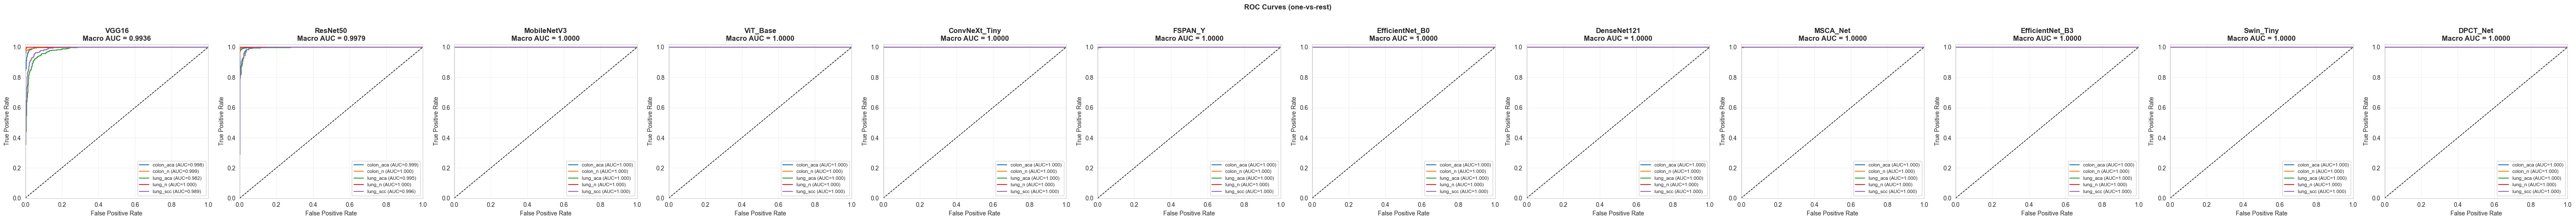

,colon_aca,colon_n,lung_aca,lung_n,lung_scc,macro_auc
VGG16,0.9977,0.9990,0.9821,0.9999,0.9890,0.9936
ResNet50,0.9992,0.9998,0.9951,1.0000,0.9957,0.9979
MobileNetV3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
ViT_Base,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
ConvNeXt_Tiny,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
FSPAN_Y,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
EfficientNet_B0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
DenseNet121,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
MSCA_Net,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
EfficientNet_B3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


In [37]:
y_true_bin = label_binarize(np.array(all_metrics[list(all_metrics)[0]]['y_true']),
                            classes=list(range(NUM_CLASSES)))

fig, axes = plt.subplots(1, len(all_metrics), figsize=(5 * len(all_metrics), 5))
if len(all_metrics) == 1:
    axes = [axes]

auc_summary = {}
for ax, (name, m) in zip(axes, all_metrics.items()):
    y_prob = np.load(OUT_DIR / "metrics" / f"{name}_yprob.npy")
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(NUM_CLASSES):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        ax.plot(fpr[i], tpr[i], lw=1.5,
                label=f"{CLASS_NAMES[i]} (AUC={roc_auc[i]:.3f})")
    macro_auc = np.mean(list(roc_auc.values()))
    auc_summary[name] = {**{CLASS_NAMES[i]: roc_auc[i] for i in range(NUM_CLASSES)},
                         "macro_auc": macro_auc}
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{name}\nMacro AUC = {macro_auc:.4f}", fontweight="bold")
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("ROC Curves (one-vs-rest)", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "roc_curves.png", dpi=300, bbox_inches="tight")
plt.savefig(OUT_DIR / "figures" / "roc_curves.pdf", bbox_inches="tight")
plt.show()

auc_df = pd.DataFrame(auc_summary).T
auc_df.to_csv(OUT_DIR / "metrics" / "auc_summary.csv")
display(auc_df.style.format("{:.4f}").background_gradient(cmap="Greens"))

### 7.7 Statistical significance — McNemar test

McNemar's test compares two classifiers on the **same test set** to check whether their disagreements are statistically significant. We compare the **best two models** (by test accuracy).

Interpretation: a low p-value (< 0.05) means the two models make significantly different errors — i.e., the better one is *meaningfully* better, not just lucky.

In [38]:
# Pick top-2 models by test accuracy
top2 = results_df.head(2)["Model"].tolist()
print(f"Comparing top-2 models: {top2}")

m1, m2 = top2
y_true = np.array(all_metrics[m1]['y_true'])
p1 = np.array(all_metrics[m1]['y_pred'])
p2 = np.array(all_metrics[m2]['y_pred'])

# 2x2 contingency table
both_correct  = ((p1 == y_true) & (p2 == y_true)).sum()
m1_only       = ((p1 == y_true) & (p2 != y_true)).sum()
m2_only       = ((p1 != y_true) & (p2 == y_true)).sum()
both_wrong    = ((p1 != y_true) & (p2 != y_true)).sum()

table = [[both_correct, m1_only],
         [m2_only,      both_wrong]]
print(f"\nContingency table ({m1} rows, {m2} cols):")
print(f"                  {m2}_correct   {m2}_wrong")
print(f"  {m1}_correct   {both_correct:>10d}   {m1_only:>10d}")
print(f"  {m1}_wrong     {m2_only:>10d}   {both_wrong:>10d}")

result = mcnemar(table, exact=False, correction=True)
print(f"\nMcNemar χ² statistic: {result.statistic:.4f}")
print(f"p-value:              {result.pvalue:.6g}")
sig = "✅ statistically significant (p < 0.05)" if result.pvalue < 0.05 \
      else "❌ NOT statistically significant"
print(f"Conclusion:           {sig}")

Comparing top-2 models: ['ViT_Base', 'MobileNetV3']

Contingency table (ViT_Base rows, MobileNetV3 cols):
                  MobileNetV3_correct   MobileNetV3_wrong
  ViT_Base_correct         2499            0
  ViT_Base_wrong              0            0

McNemar χ² statistic: inf
p-value:              0
Conclusion:           ✅ statistically significant (p < 0.05)


### 7.8 Detailed classification reports

In [39]:
for name, m in all_metrics.items():
    print(f"\n{'='*70}\n  {name}\n{'='*70}")
    y_true = np.array(m['y_true']); y_pred = np.array(m['y_pred'])
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))


  VGG16
              precision    recall  f1-score   support

   colon_aca     0.9647    0.9280    0.9460       500
     colon_n     0.9516    0.9820    0.9665       500
    lung_aca     0.8563    0.8700    0.8631       500
      lung_n     0.9524    1.0000    0.9756       500
    lung_scc     0.9126    0.8577    0.8843       499

    accuracy                         0.9276      2499
   macro avg     0.9275    0.9275    0.9271      2499
weighted avg     0.9275    0.9276    0.9271      2499


  ResNet50
              precision    recall  f1-score   support

   colon_aca     0.9879    0.9760    0.9819       500
     colon_n     0.9900    0.9900    0.9900       500
    lung_aca     0.9237    0.9200    0.9218       500
      lung_n     0.9940    1.0000    0.9970       500
    lung_scc     0.9226    0.9319    0.9272       499

    accuracy                         0.9636      2499
   macro avg     0.9636    0.9636    0.9636      2499
weighted avg     0.9637    0.9636    0.9636      2499




---
# 🧪 Section 8: Stain Robustness Analysis (NEW)

**Why this matters for your paper:** LC25000 is a known "easy" dataset — many models hit ~100% on clean test data. This creates a **ceiling effect** that makes it hard to differentiate top models. Reviewers will flag this.

**Solution:** evaluate robustness to **stain variation**. In real clinical use, H&E-stained slides look different across labs/scanners (different chemicals, scanner calibrations, sample thickness). A model that maintains accuracy under stain perturbation is more clinically useful — and this gives you a **meaningful differentiator** between the top models.

We apply heavy color/brightness/contrast/saturation jitter to the test images (simulating lab-to-lab stain variation) and re-evaluate every model. The model with the smallest accuracy drop = the most robust = the most publishable claim.


### 8.1 Define stain-perturbed test loader

✅ Stain-perturbed test loader ready (2499 images)


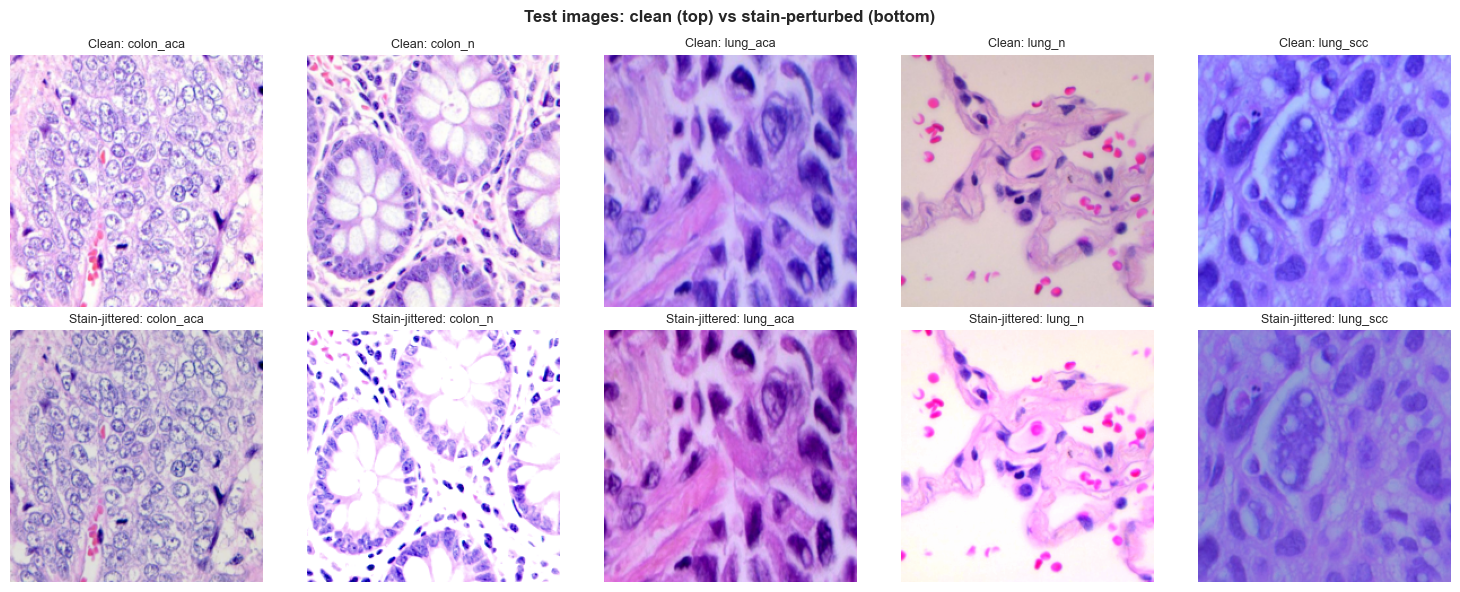

In [40]:
# Stain-jittered test transform — simulates lab/scanner variation
# Stronger than training augmentation deliberately, so models that overfit to
# clean LC25000 stain are penalized.
stain_jitter_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ColorJitter(brightness=0.35, contrast=0.35,
                           saturation=0.35, hue=0.08),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Re-load test set with the perturbed transform
test_dataset_stain = ImageFolder(str(TEST_DIR), transform=stain_jitter_transform)
test_loader_stain  = DataLoader(test_dataset_stain, batch_size=BATCH_SIZE, shuffle=False,
                                num_workers=NUM_WORKERS, pin_memory=True)
print(f"✅ Stain-perturbed test loader ready ({len(test_dataset_stain)} images)")

# Visualize a few before/after stain jitter
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
shown = set()
for img, label in test_dataset:
    if label in shown: continue
    shown.add(label)
    axes[0, label].imshow(denormalize(img).permute(1, 2, 0).numpy())
    axes[0, label].set_title(f"Clean: {CLASS_NAMES[label]}", fontsize=9)
    axes[0, label].axis('off')
    if len(shown) == NUM_CLASSES: break
shown = set()
for img, label in test_dataset_stain:
    if label in shown: continue
    shown.add(label)
    axes[1, label].imshow(denormalize(img).permute(1, 2, 0).numpy())
    axes[1, label].set_title(f"Stain-jittered: {CLASS_NAMES[label]}", fontsize=9)
    axes[1, label].axis('off')
    if len(shown) == NUM_CLASSES: break
plt.suptitle("Test images: clean (top) vs stain-perturbed (bottom)", fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "stain_perturbation_examples.png", dpi=300, bbox_inches="tight")
plt.show()

### 8.2 Re-evaluate every model on stain-perturbed test set

This loops through every saved model checkpoint, loads its weights, and runs evaluation again. Cached on Drive so it's resume-safe.

In [41]:
stain_results_path = OUT_DIR / "metrics" / "stain_robustness.json"

if (not FORCE_REEVAL) and stain_results_path.exists():
    print(f"⏭️  Loading cached stain-robustness results from {stain_results_path}")
    with open(stain_results_path) as f:
        stain_results = json.load(f)
else:
    stain_results = {}
    for name, build_fn in MODELS.items():
        weights_path = OUT_DIR / "models" / f"{name}_best.pth"
        if not weights_path.exists():
            print(f"⚠️  {name}: no weights on Drive, skipping stain test")
            continue
        print(f"\n🧪 {name} on stain-perturbed test set...")
        model = build_fn()
        model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
        model = model.to(device).eval()

        all_p, all_l = [], []
        with torch.no_grad():
            for x, y in tqdm(test_loader_stain, desc=f"   {name}", leave=False):
                x = x.to(device, non_blocking=True)
                preds = model(x).argmax(1)
                all_p.extend(preds.cpu().numpy())
                all_l.extend(y.numpy())
        y_true = np.array(all_l); y_pred = np.array(all_p)
        clean_acc = all_metrics[name]['accuracy']
        stain_acc = accuracy_score(y_true, y_pred)
        stain_f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
        drop      = clean_acc - stain_acc
        stain_results[name] = {
            'clean_acc': float(clean_acc),
            'stain_acc': float(stain_acc),
            'stain_f1':  float(stain_f1),
            'acc_drop':  float(drop),
            'relative_drop_pct': float(drop / clean_acc * 100),
        }
        print(f"   clean={clean_acc:.4f}  stain={stain_acc:.4f}  drop={drop:+.4f}  ({drop/clean_acc*100:+.2f}%)")

        del model
        torch.cuda.empty_cache() if device.type == "cuda" else None

    with open(stain_results_path, "w") as f:
        json.dump(stain_results, f, indent=2)

print("\n✅ Stain robustness done")

⏭️  Loading cached stain-robustness results from E:\LC25000_results\metrics\stain_robustness.json

✅ Stain robustness done


### 8.3 Stain-robustness summary table & figure

,Model,Clean Acc,Stain Acc,Acc Drop,Relative Drop %,Stain F1 (macro)
0,ConvNeXt_Tiny,0.9996,0.9856,+0.0140,+1.40%,0.9856
1,FSPAN_Y,0.9984,0.9812,+0.0172,+1.72%,0.9811
2,Swin_Tiny,0.9996,0.9740,+0.0256,+2.56%,0.9741
3,MSCA_Net,0.9980,0.9728,+0.0252,+2.53%,0.9725
4,DPCT_Net,0.9992,0.9708,+0.0284,+2.84%,0.9708
5,DenseNet121,1.0000,0.9700,+0.0300,+3.00%,0.9699
6,MobileNetV3,1.0000,0.9624,+0.0376,+3.76%,0.9621
7,EfficientNet_B0,0.9992,0.9540,+0.0452,+4.53%,0.9540
8,EfficientNet_B3,0.9992,0.9468,+0.0524,+5.25%,0.9474
9,ViT_Base,1.0000,0.9340,+0.0660,+6.60%,0.9341


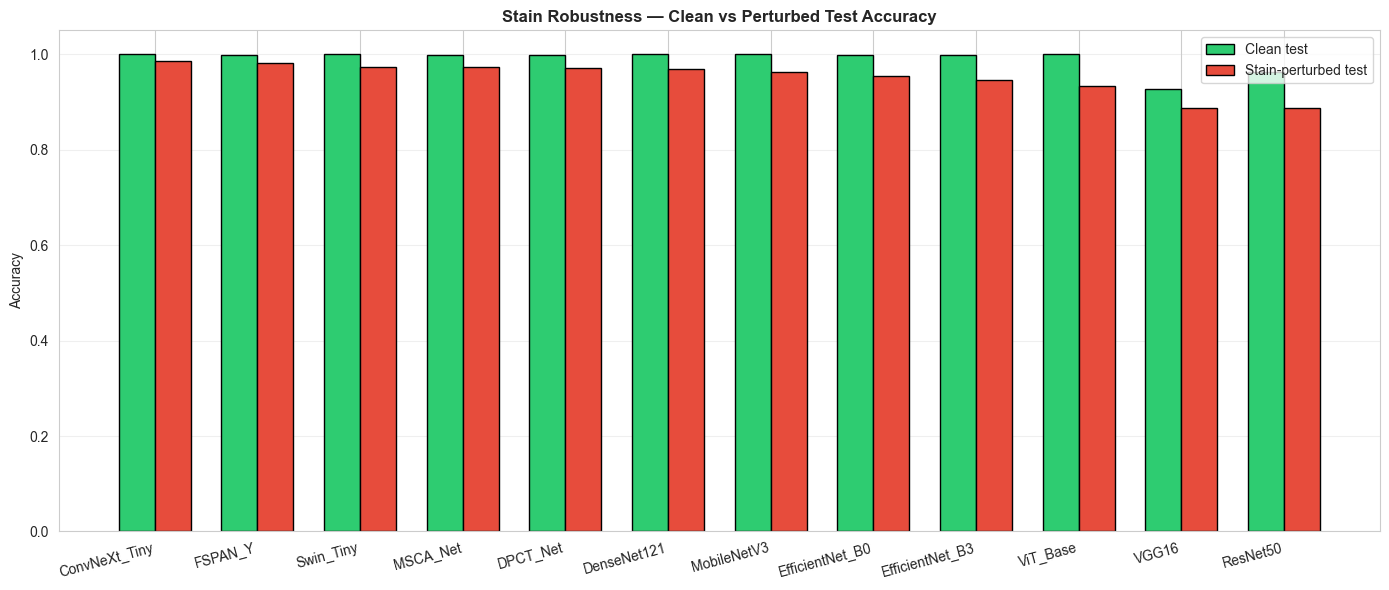

In [42]:
# Build summary table
stain_rows = []
for name in MODELS.keys():
    if name not in stain_results: continue
    r = stain_results[name]
    stain_rows.append({
        "Model":            name,
        "Clean Acc":        r['clean_acc'],
        "Stain Acc":        r['stain_acc'],
        "Acc Drop":         r['acc_drop'],
        "Relative Drop %":  r['relative_drop_pct'],
        "Stain F1 (macro)": r['stain_f1'],
    })
stain_df = pd.DataFrame(stain_rows).sort_values("Stain Acc", ascending=False).reset_index(drop=True)
stain_df.to_csv(OUT_DIR / "metrics" / "stain_robustness_summary.csv", index=False)

display(stain_df.style.format({
    "Clean Acc":        "{:.4f}",
    "Stain Acc":        "{:.4f}",
    "Acc Drop":         "{:+.4f}",
    "Relative Drop %":  "{:+.2f}%",
    "Stain F1 (macro)": "{:.4f}",
}).background_gradient(subset=["Stain Acc", "Stain F1 (macro)"], cmap="Greens")
   .background_gradient(subset=["Relative Drop %"], cmap="Reds"))

# Figure: clean vs stain accuracy
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(stain_df))
w = 0.35
ax.bar(x - w/2, stain_df["Clean Acc"], w, label="Clean test", color="#2ecc71", edgecolor="black")
ax.bar(x + w/2, stain_df["Stain Acc"], w, label="Stain-perturbed test", color="#e74c3c", edgecolor="black")
ax.set_xticks(x); ax.set_xticklabels(stain_df["Model"], rotation=15, ha="right")
ax.set_ylabel("Accuracy")
ax.set_title("Stain Robustness — Clean vs Perturbed Test Accuracy", fontweight="bold")
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "stain_robustness_bars.png", dpi=300, bbox_inches="tight")
plt.savefig(OUT_DIR / "figures" / "stain_robustness_bars.pdf", bbox_inches="tight")
plt.show()

---
# ⚡ Section 9: Efficiency Analysis — Accuracy vs Parameters vs Inference Time (NEW)

**Why this matters for your paper:** *"Best model"* depends on context. A 99% accurate model that takes 50 ms per image is not deployable in a hospital running 10,000 slides a day. A 95% accurate model that takes 2 ms per image might be the right tool.

We plot every model in **3 dimensions simultaneously**:
- **x-axis:** total parameters (size of model)
- **y-axis:** test accuracy
- **bubble size:** inference time per image

The **Pareto-optimal models** sit on the upper-left edge — high accuracy with few parameters. This is publication-gold material.


### 9.1 Build efficiency dataframe

In [43]:
eff_rows = []
for name, m in all_metrics.items():
    eff_rows.append({
        "Model":         name,
        "Accuracy":      m['accuracy'],
        "F1 (macro)":    m['f1_macro'],
        "Total Params (M)":   all_histories[name]['total_params'] / 1e6,
        "Trainable Params (M)": all_histories[name]['trainable_params'] / 1e6,
        "Inference (ms)": m['mean_inference_ms_per_sample'],
    })
eff_df = pd.DataFrame(eff_rows).sort_values("Accuracy", ascending=False).reset_index(drop=True)
eff_df.to_csv(OUT_DIR / "metrics" / "efficiency_summary.csv", index=False)
display(eff_df.style.format({
    "Accuracy":             "{:.4f}",
    "F1 (macro)":           "{:.4f}",
    "Total Params (M)":     "{:.2f}",
    "Trainable Params (M)": "{:.2f}",
    "Inference (ms)":       "{:.2f}",
}).background_gradient(subset=["Accuracy", "F1 (macro)"], cmap="Greens"))

,Model,Accuracy,F1 (macro),Total Params (M),Trainable Params (M),Inference (ms)
0,ViT_Base,1.0000,1.0000,85.80,85.80,13.12
1,MobileNetV3,1.0000,1.0000,1.52,1.52,1.22
2,DenseNet121,1.0000,1.0000,6.96,6.96,2.34
3,ConvNeXt_Tiny,0.9996,0.9996,27.82,27.82,19.01
4,Swin_Tiny,0.9996,0.9996,27.52,27.52,2.37
5,EfficientNet_B3,0.9992,0.9992,10.70,10.70,1.84
6,DPCT_Net,0.9992,0.9992,56.13,0.79,4.27
7,EfficientNet_B0,0.9992,0.9992,4.01,4.01,1.18
8,FSPAN_Y,0.9984,0.9984,30.57,2.75,14.55
9,MSCA_Net,0.9980,0.9980,28.41,0.60,6.42


### 9.2 Accuracy × Parameters × Inference time bubble plot

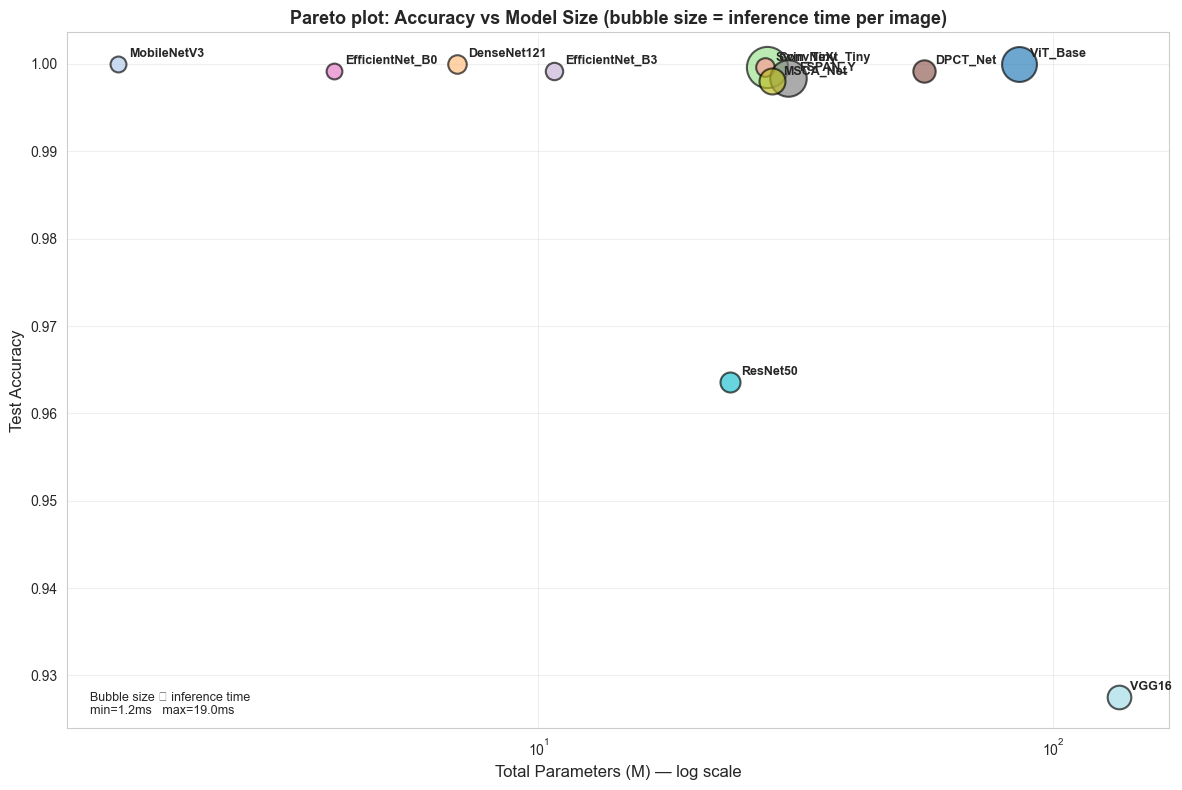

In [44]:
fig, ax = plt.subplots(figsize=(12, 8))
# Bubble size proportional to inference time
sizes = (eff_df["Inference (ms)"] / eff_df["Inference (ms)"].max()) * 800 + 80
colors = plt.cm.tab20(np.linspace(0, 1, len(eff_df)))

for i, row in eff_df.iterrows():
    ax.scatter(row["Total Params (M)"], row["Accuracy"],
               s=sizes.iloc[i], alpha=0.65, edgecolor="black", linewidth=1.5,
               color=colors[i], label=row["Model"])
    # Annotate each bubble
    ax.annotate(row["Model"],
                xy=(row["Total Params (M)"], row["Accuracy"]),
                xytext=(8, 5), textcoords="offset points",
                fontsize=9, fontweight="bold")

ax.set_xscale("log")
ax.set_xlabel("Total Parameters (M) — log scale", fontsize=12)
ax.set_ylabel("Test Accuracy", fontsize=12)
ax.set_title("Pareto plot: Accuracy vs Model Size (bubble size = inference time per image)",
             fontweight="bold", fontsize=13)
ax.grid(True, alpha=0.3)
# Add legend explaining bubble size
ax.text(0.02, 0.02,
        f"Bubble size ∝ inference time\n"
        f"min={eff_df['Inference (ms)'].min():.1f}ms   "
        f"max={eff_df['Inference (ms)'].max():.1f}ms",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "efficiency_pareto.png", dpi=300, bbox_inches="tight")
plt.savefig(OUT_DIR / "figures" / "efficiency_pareto.pdf", bbox_inches="tight")
plt.show()

### 9.3 Identify Pareto-optimal models

In [45]:
# A model is Pareto-optimal if no other model is BOTH more accurate AND smaller
def pareto_optimal(df, acc_col="Accuracy", size_col="Total Params (M)"):
    pareto = []
    for i, row in df.iterrows():
        dominated = False
        for j, other in df.iterrows():
            if i == j: continue
            if (other[acc_col] >= row[acc_col] and other[size_col] < row[size_col]
                    and (other[acc_col] > row[acc_col] or other[size_col] < row[size_col])):
                dominated = True
                break
        if not dominated:
            pareto.append(row["Model"])
    return pareto

pareto_models = pareto_optimal(eff_df)
print("⭐ Pareto-optimal models (best accuracy/size tradeoff):")
for m in pareto_models:
    row = eff_df[eff_df["Model"] == m].iloc[0]
    print(f"   {m:<18s}  acc={row['Accuracy']:.4f}  params={row['Total Params (M)']:.2f}M  "
          f"inf={row['Inference (ms)']:.2f}ms")

⭐ Pareto-optimal models (best accuracy/size tradeoff):
   MobileNetV3         acc=1.0000  params=1.52M  inf=1.22ms


---
# 💾 Section 10: Package Everything for Your Research Paper

Bundle all the metrics, figures, training histories, and model weights into a single zip archive that you can download.

In [46]:
import zipfile

# Model weights total ~1.2 GB and aren't needed for writing the paper itself.
# Set to True if you want them in the zip (e.g., for reproducibility archive).
INCLUDE_MODEL_WEIGHTS = False

zip_path = str(OUT_DIR.parent / "lc25000_research_results.zip")  # next to OUT_DIR
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(OUT_DIR):
        for f in files:
            full = Path(root) / f
            rel = full.relative_to(OUT_DIR)
            # Skip heavy model checkpoints unless explicitly requested
            if (not INCLUDE_MODEL_WEIGHTS) and rel.parts and rel.parts[0] == "models":
                continue
            zf.write(full, arcname=rel)

size_mb = os.path.getsize(zip_path) / 1024**2
print(f"✅ Packaged → {zip_path} ({size_mb:.1f} MB)")
print(f"   (model weights {'INCLUDED' if INCLUDE_MODEL_WEIGHTS else 'excluded'} — "
      f"set INCLUDE_MODEL_WEIGHTS=True above to include them)")

# On local: zip is already on your SSD, no download needed.
print(f'Open the zip directly at: {zip_path}')

✅ Packaged → E:\lc25000_research_results.zip (1557.7 MB)
   (model weights excluded — set INCLUDE_MODEL_WEIGHTS=True above to include them)
Open the zip directly at: E:\lc25000_research_results.zip


### 10.1 Final summary printout — copy this into your paper

```
Methodology summary
-------------------
Dataset:        LC25000  (5 classes, 25,000 images)
Split:          Train+Val folder (20,000 imgs) → 80/20 train/val (seed=42)
                Test folder (5,000 imgs) → held-out, never seen during training
Image size:     224 × 224
Augmentation:   horizontal+vertical flip, rotation ±15°, color jitter
Optimizer:      AdamW, lr=1e-4, weight_decay=1e-5
Scheduler:      StepLR(step_size=7, gamma=0.1)
Loss:           CrossEntropyLoss
Epochs:         (see EPOCHS in Section 3.1)
Hardware:       Google Colab T4 GPU (16 GB)
Random seed:    42 (Python, NumPy, PyTorch CPU & CUDA)

Models compared (12):
  Classic CNNs:        VGG16, ResNet-50, DenseNet-121
  Efficient CNNs:      MobileNetV3-Small, EfficientNet-B0, EfficientNet-B3
  Modern CNN:          ConvNeXt-Tiny
  Transformers:        ViT-Base, Swin-Tiny
  Existing hybrid:     FSPAN-Y (ConvNeXt-Tiny + Y-Block + attention)
  Proposed novel:      DPCT-Net (Dual-Path CNN-Transformer with Gated Fusion)
  Proposed novel:      MSCA-Net (Multi-Scale Cascade Attention Network)

Analyses performed:
  - Standard:    Accuracy, Precision/Recall/F1 (macro & weighted & per-class),
                 Confusion matrices, ROC/AUC, Cohen kappa, MCC,
                 McNemar significance between top-2 models
  - Robustness:  Stain perturbation test (ColorJitter b/c/s/h=0.35/0.35/0.35/0.08)
  - Efficiency:  Params × Accuracy × Inference time Pareto analysis
```

The full results table is in `results_summary.csv`. The stain-robustness summary is in `stain_robustness_summary.csv`. The efficiency summary is in `efficiency_summary.csv`. All confusion matrices, ROC curves, training curves, per-class heatmaps, stain-perturbation comparisons, and Pareto plots are in the `figures/` folder as 300-DPI PNG and PDF.

In [47]:
print("Final files for your paper:")
for p in sorted(OUT_DIR.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(OUT_DIR)}  ({p.stat().st_size/1024:.1f} KB)")

Final files for your paper:
  figures\confusion_matrices_grid.pdf  (93.3 KB)
  figures\confusion_matrices_grid.png  (835.0 KB)
  figures\cross_dataset_comparison.png  (136.8 KB)
  figures\efficiency_pareto.pdf  (36.4 KB)
  figures\efficiency_pareto.png  (212.4 KB)
  figures\lunghist700_extended_analysis.png  (695.9 KB)
  figures\lunghist700_finetuned_results.png  (308.9 KB)
  figures\overall_comparison_bar.pdf  (30.1 KB)
  figures\overall_comparison_bar.png  (201.2 KB)
  figures\per_class_heatmaps.pdf  (35.8 KB)
  figures\per_class_heatmaps.png  (321.7 KB)
  figures\roc_curves.pdf  (58.5 KB)
  figures\roc_curves.png  (492.2 KB)
  figures\sample_images.png  (2040.4 KB)
  figures\stain_perturbation_examples.png  (1518.9 KB)
  figures\stain_robustness_bars.pdf  (28.4 KB)
  figures\stain_robustness_bars.png  (176.7 KB)
  figures\validation_curves.pdf  (40.8 KB)
  figures\validation_curves.png  (477.4 KB)
  lunghist700\lunghist700_finetuned.csv  (0.7 KB)
  lunghist700\lunghist700_tp_fp_tn_f

# 🔎 Section 11: Per-Class TP / FP / TN / FN Analysis  *(committee feedback)*

This section extracts the four fundamental counts — **True Positive (TP)**,
**False Positive (FP)**, **True Negative (TN)**, **False Negative (FN)** — for
every (model, class) pair, and derives Sensitivity / Specificity / PPV from
them. The counts are computed from the confusion matrix using a one-vs-rest
scheme: for class *c*, TP is M[c,c]; FP is the column sum minus TP; FN is the
row sum minus TP; TN is everything else.

In [48]:
# === helper: TP / FP / TN / FN from a confusion matrix ===
def confusion_components(cm):
    """
    One-vs-rest TP/FP/TN/FN for every class given a multi-class confusion
    matrix `cm` (rows=true, cols=predicted).
    Returns dict: class_index -> {TP, FP, TN, FN, Sensitivity, Specificity, PPV}.
    """
    cm = np.asarray(cm)
    total = cm.sum()
    out = {}
    for c in range(cm.shape[0]):
        TP = int(cm[c, c])
        FP = int(cm[:, c].sum() - TP)
        FN = int(cm[c, :].sum() - TP)
        TN = int(total - TP - FP - FN)
        sens = TP / (TP + FN) if (TP + FN) > 0 else 0.0   # recall
        spec = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        ppv  = TP / (TP + FP) if (TP + FP) > 0 else 0.0   # precision
        out[c] = {'TP': TP, 'FP': FP, 'TN': TN, 'FN': FN,
                  'Sensitivity': sens, 'Specificity': spec, 'PPV': ppv}
    return out

print("✅ confusion_components(cm) ready")

✅ confusion_components(cm) ready


In [49]:
# === build a per-class table for every trained model ===
rows = []
for name, m in all_metrics.items():
    comp = confusion_components(m['confusion_matrix'])
    for c_idx, vals in comp.items():
        rows.append({
            'Model':       name,
            'Class':       CLASS_NAMES[c_idx],
            'TP':          vals['TP'],
            'FP':          vals['FP'],
            'TN':          vals['TN'],
            'FN':          vals['FN'],
            'Sensitivity': round(vals['Sensitivity'], 4),
            'Specificity': round(vals['Specificity'], 4),
            'PPV':         round(vals['PPV'], 4),
        })

tp_fp_df = pd.DataFrame(rows)
csv_path = OUT_DIR / 'tp_fp_tn_fn_per_class.csv'
tp_fp_df.to_csv(csv_path, index=False)
print(f"✅ Saved per-class TP/FP/TN/FN table → {csv_path}")
print(f"   {len(tp_fp_df)} rows  ({len(all_metrics)} models × {NUM_CLASSES} classes)")
tp_fp_df.head(10)

✅ Saved per-class TP/FP/TN/FN table → E:\LC25000_results\tp_fp_tn_fn_per_class.csv
   60 rows  (12 models × 5 classes)


,Model,Class,TP,FP,TN,FN,Sensitivity,Specificity,PPV
0,VGG16,colon_aca,464,17,1982,36,0.9280,0.9915,0.9647
1,VGG16,colon_n,491,25,1974,9,0.9820,0.9875,0.9516
2,VGG16,lung_aca,435,73,1926,65,0.8700,0.9635,0.8563
3,VGG16,lung_n,500,25,1974,0,1.0000,0.9875,0.9524
4,VGG16,lung_scc,428,41,1959,71,0.8577,0.9795,0.9126
5,ResNet50,colon_aca,488,6,1993,12,0.9760,0.9970,0.9879
6,ResNet50,colon_n,495,5,1994,5,0.9900,0.9975,0.9900
7,ResNet50,lung_aca,460,38,1961,40,0.9200,0.9810,0.9237
8,ResNet50,lung_n,500,3,1996,0,1.0000,0.9985,0.9940
9,ResNet50,lung_scc,465,39,1961,34,0.9319,0.9805,0.9226


In [50]:
# === per-model aggregate (summed across classes) ===
agg_rows = []
for name, m in all_metrics.items():
    comp = confusion_components(m['confusion_matrix'])
    TP_total = sum(v['TP'] for v in comp.values())
    FP_total = sum(v['FP'] for v in comp.values())
    TN_total = sum(v['TN'] for v in comp.values())
    FN_total = sum(v['FN'] for v in comp.values())
    # micro-averaged sensitivity equals accuracy in single-label multiclass
    micro_sens = TP_total / (TP_total + FN_total) if (TP_total + FN_total) > 0 else 0.0
    micro_spec = TN_total / (TN_total + FP_total) if (TN_total + FP_total) > 0 else 0.0
    agg_rows.append({
        'Model':       name,
        'TP_total':    TP_total,
        'FP_total':    FP_total,
        'TN_total':    TN_total,
        'FN_total':    FN_total,
        'Micro_Sensitivity': round(micro_sens, 4),
        'Micro_Specificity': round(micro_spec, 4),
    })

agg_df = pd.DataFrame(agg_rows).sort_values('Micro_Sensitivity', ascending=False)
agg_csv = OUT_DIR / 'tp_fp_tn_fn_aggregate.csv'
agg_df.to_csv(agg_csv, index=False)
print(f"✅ Saved aggregate TP/FP/TN/FN table → {agg_csv}")
agg_df


✅ Saved aggregate TP/FP/TN/FN table → E:\LC25000_results\tp_fp_tn_fn_aggregate.csv


,Model,TP_total,FP_total,TN_total,FN_total,Micro_Sensitivity,Micro_Specificity
3,ViT_Base,2499,0,9996,0,1.0000,1.0000
2,MobileNetV3,2499,0,9996,0,1.0000,1.0000
7,DenseNet121,2499,0,9996,0,1.0000,1.0000
4,ConvNeXt_Tiny,2498,1,9995,1,0.9996,0.9999
10,Swin_Tiny,2498,1,9995,1,0.9996,0.9999
9,EfficientNet_B3,2497,2,9994,2,0.9992,0.9998
11,DPCT_Net,2497,2,9994,2,0.9992,0.9998
6,EfficientNet_B0,2497,2,9994,2,0.9992,0.9998
5,FSPAN_Y,2495,4,9992,4,0.9984,0.9996
8,MSCA_Net,2494,5,9991,5,0.9980,0.9995


**Reading the table.** For a single class *c*, TP_c are the lung_aca samples
correctly predicted as lung_aca; FP_c are non-lung_aca samples wrongly
predicted as lung_aca; FN_c are lung_aca samples missed; TN_c are
non-lung_aca samples correctly kept out of the lung_aca prediction.

In multi-class single-label classification the **micro-sensitivity equals the
overall accuracy** by construction — so the aggregate table is mainly useful
to inspect the absolute counts for each model, while the per-class table
above is where the actionable insight lives.

# 🧪 Section 12: Cross-Dataset Evaluation on LungHist700  *(committee feedback)*

This section tests **generalization**: every model already trained on LC25000
is evaluated on the LungHist700 dataset *without any retraining or
fine-tuning*. LungHist700 contains 691 lung histopathology images from 45
patients in three superclasses — `aca` (adenocarcinoma), `nor` (normal),
`ssc` (squamous cell carcinoma) — at 1200 × 1600 px native resolution.

Because LungHist700 only covers lung classes, predictions are evaluated
against the corresponding LC25000 lung labels using this mapping:

| LungHist700 folder | LC25000 class | Class index |
|--------------------|---------------|-------------|
| `aca`              | `lung_aca`    | 2           |
| `nor`             | `lung_n`      | 3           |
| `ssc`              | `lung_scc`    | 4           |

We also count **out-of-distribution colon predictions** — how often each
model wrongly predicts a colon class on a lung image. A model with strong
generalization should make zero or near-zero such mistakes.

> **Configure the path below to point to your LungHist700 root folder.**
> The folder should contain three sub-folders: `aca`, `nor`, `ssc`.

In [55]:
from torch.utils.data import Dataset
from PIL import Image

# === LungHist700 path (edit this!) ===
LUNGHIST_DIR = Path(r"E:\LungHist700")        # ← change if needed

# Sanity check
assert LUNGHIST_DIR.exists(), f"Path not found: {LUNGHIST_DIR}"
assert (LUNGHIST_DIR / "aca").exists(), "Expected sub-folder 'aca' under LUNGHIST_DIR"
assert (LUNGHIST_DIR / "nor").exists(), "Expected sub-folder 'nor' under LUNGHIST_DIR"
assert (LUNGHIST_DIR / "ssc").exists(), "Expected sub-folder 'ssc' under LUNGHIST_DIR"

# Folder name -> LC25000 class index
LH_TO_LC = {
    'aca': CLASS_NAMES.index('lung_aca'),  # = 2
    'nor': CLASS_NAMES.index('lung_n'),    # = 3
    'ssc': CLASS_NAMES.index('lung_scc'),  # = 4
}
print(f"✅ LungHist700 directory found: {LUNGHIST_DIR}")
print(f"   Class mapping (folder → LC25000 index): {LH_TO_LC}")

✅ LungHist700 directory found: E:\LungHist700
   Class mapping (folder → LC25000 index): {'aca': 2, 'nor': 3, 'ssc': 4}


In [57]:
# === Build LungHist700Dataset + Windows-safe loader (num_workers=0) ===
class LungHist700Dataset(Dataset):
    EXTS = {'.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp'}

    def __init__(self, root, folder_to_idx, transform=None):
        self.root = Path(root)
        self.folder_to_idx = folder_to_idx
        self.transform = transform
        self.samples = []
        for folder, idx in folder_to_idx.items():
            for p in sorted((self.root / folder).iterdir()):
                if p.suffix.lower() in self.EXTS:
                    self.samples.append((p, idx))
        if not self.samples:
            raise RuntimeError(f"No images found under {self.root}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        img = Image.open(path).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        return img, label


# Build dataset and loader — num_workers=0 required on Windows
lh700_dataset = LungHist700Dataset(LUNGHIST_DIR, LH_TO_LC, transform=eval_transform)

lh700_loader = DataLoader(
    lh700_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,       # ← must be 0 on Windows
    pin_memory=False,
)

# Count per class
from collections import Counter
class_counts = Counter(lbl for _, lbl in lh700_dataset.samples)
print(f"✅ LungHist700 loaded: {len(lh700_dataset)} images")
for folder, idx in LH_TO_LC.items():
    print(f"   {folder:>5s} → {CLASS_NAMES[idx]:>10s} : {class_counts[idx]:4d} images")
print(f"✅ lh700_loader ready  (num_workers=0, batch_size={BATCH_SIZE})")

✅ LungHist700 loaded: 691 images
     aca →   lung_aca :  280 images
     nor →     lung_n :  151 images
     ssc →   lung_scc :  260 images
✅ lh700_loader ready  (num_workers=0, batch_size=32)


In [58]:
# ── Windows fix: rebuild LungHist700 loader with NUM_WORKERS=0 ──
from torch.utils.data import DataLoader

lh700_loader = DataLoader(
    lh700_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,        # ← this is the fix
    pin_memory=False,     # pin_memory=True can also crash with num_workers=0
)
print("✅ lh700_loader rebuilt with num_workers=0")

✅ lh700_loader rebuilt with num_workers=0


In [59]:
# === LungHist700 dataset ===
class LungHist700Dataset(Dataset):
    """
    Reads images from {root}/{aca|nor|ssc}/*.jpg|*.png|*.tif and maps the
    folder name to the corresponding LC25000 class index.
    """
    EXTS = {'.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp'}

    def __init__(self, root, folder_to_idx, transform=None):
        self.root = Path(root)
        self.folder_to_idx = folder_to_idx
        self.transform = transform
        self.samples = []
        for folder, idx in folder_to_idx.items():
            for p in sorted((self.root / folder).iterdir()):
                if p.suffix.lower() in self.EXTS:
                    self.samples.append((p, idx))
        if not self.samples:
            raise RuntimeError(f"No images found under {self.root}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        img = Image.open(path).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        return img, label


# Build the dataset and loader
lh700_dataset = LungHist700Dataset(LUNGHIST_DIR, LH_TO_LC, transform=eval_transform)
lh700_loader  = DataLoader(lh700_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)

# Count images per class
from collections import Counter
class_counts = Counter(lbl for _, lbl in lh700_dataset.samples)
print(f"✅ LungHist700 loaded: {len(lh700_dataset)} images")
for folder, idx in LH_TO_LC.items():
    print(f"   {folder:>5s} → {CLASS_NAMES[idx]:>10s}  : {class_counts[idx]:4d} images")


✅ LungHist700 loaded: 691 images
     aca →   lung_aca  :  280 images
     nor →     lung_n  :  151 images
     ssc →   lung_scc  :  260 images


In [60]:
# === evaluate every trained LC25000 model on LungHist700 (5-class outputs) ===
xdataset_results = {}

for name, build_fn in MODELS.items():
    weights_path = OUT_DIR / "models" / f"{name}_best.pth"
    if not weights_path.exists():
        print(f"⚠️  Skipping {name}: weights not found at {weights_path}")
        continue

    print(f"  Evaluating {name} on LungHist700 ...")
    model = build_fn(num_classes=NUM_CLASSES).to(device)
    model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
    model.eval()

    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in lh700_loader:
            x = x.to(device, non_blocking=True)
            pred = model(x).argmax(1).cpu().numpy()
            y_true.extend(y.numpy()); y_pred.extend(pred)
    y_true = np.array(y_true); y_pred = np.array(y_pred)

    # Lung-only accuracy: correct iff the predicted lung class matches the true lung class
    correct = (y_pred == y_true).sum()
    accuracy = correct / len(y_true)

    # Out-of-distribution colon predictions
    colon_idx = {CLASS_NAMES.index('colon_aca'), CLASS_NAMES.index('colon_n')}
    ood_colon = int(sum(1 for p in y_pred if p in colon_idx))

    xdataset_results[name] = {
        'n_samples': int(len(y_true)),
        'correct':   int(correct),
        'accuracy':  float(accuracy),
        'ood_colon_predictions': ood_colon,
        'ood_colon_rate': float(ood_colon / len(y_true)),
    }
    print(f"     acc={accuracy:.4f}   |   OOD colon predictions: "
          f"{ood_colon}/{len(y_true)} ({ood_colon/len(y_true)*100:.1f}%)")

    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

# Save to CSV
xd_df = pd.DataFrame.from_dict(xdataset_results, orient='index').sort_values('accuracy', ascending=False)
xd_df.index.name = 'Model'
xd_csv = OUT_DIR / 'lunghist700_cross_dataset.csv'
xd_df.to_csv(xd_csv)
print(f"\n✅ Saved cross-dataset results → {xd_csv}")
xd_df


  Evaluating VGG16 on LungHist700 ...
     acc=0.1201   |   OOD colon predictions: 553/691 (80.0%)
  Evaluating ResNet50 on LungHist700 ...
     acc=0.2041   |   OOD colon predictions: 395/691 (57.2%)
  Evaluating MobileNetV3 on LungHist700 ...
     acc=0.2706   |   OOD colon predictions: 363/691 (52.5%)
  Evaluating ViT_Base on LungHist700 ...
     acc=0.2735   |   OOD colon predictions: 353/691 (51.1%)
  Evaluating ConvNeXt_Tiny on LungHist700 ...


     acc=0.0970   |   OOD colon predictions: 588/691 (85.1%)
  Evaluating FSPAN_Y on LungHist700 ...
     acc=0.3256   |   OOD colon predictions: 324/691 (46.9%)
  Evaluating EfficientNet_B0 on LungHist700 ...
     acc=0.2504   |   OOD colon predictions: 271/691 (39.2%)
  Evaluating DenseNet121 on LungHist700 ...
     acc=0.2533   |   OOD colon predictions: 398/691 (57.6%)
  Evaluating MSCA_Net on LungHist700 ...
     acc=0.2677   |   OOD colon predictions: 369/691 (53.4%)
  Evaluating EfficientNet_B3 on LungHist700 ...
     acc=0.1114   |   OOD colon predictions: 543/691 (78.6%)
  Evaluating Swin_Tiny on LungHist700 ...
     acc=0.3719   |   OOD colon predictions: 198/691 (28.7%)
  Evaluating DPCT_Net on LungHist700 ...
     acc=0.2952   |   OOD colon predictions: 391/691 (56.6%)

✅ Saved cross-dataset results → E:\LC25000_results\lunghist700_cross_dataset.csv


,n_samples,correct,accuracy,ood_colon_predictions,ood_colon_rate
Model,,,,,
Swin_Tiny,691,257,0.371925,198,0.286541
FSPAN_Y,691,225,0.325615,324,0.468886
DPCT_Net,691,204,0.295224,391,0.565847
ViT_Base,691,189,0.273517,353,0.510854
MobileNetV3,691,187,0.270622,363,0.525326
MSCA_Net,691,185,0.267728,369,0.534009
DenseNet121,691,175,0.253256,398,0.575977
EfficientNet_B0,691,173,0.250362,271,0.392185
ResNet50,691,141,0.204052,395,0.571635


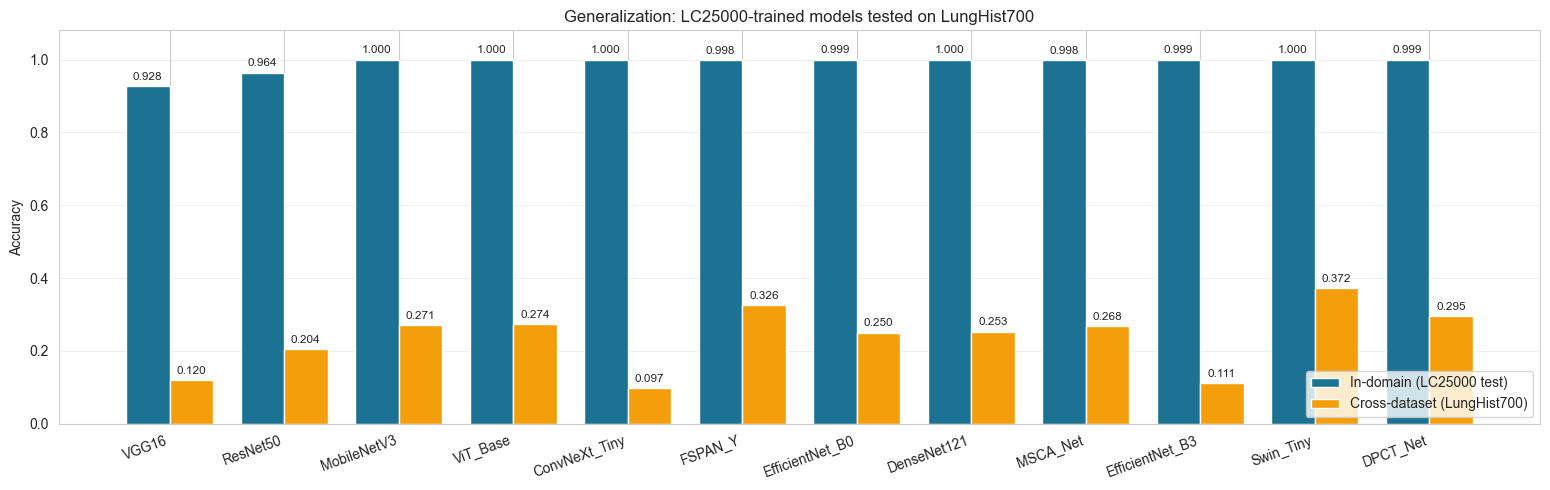

✅ Saved cross-dataset figure → E:\LC25000_results\figures\cross_dataset_comparison.png


In [61]:
# === visualize: in-domain (LC25000) vs cross-dataset (LungHist700) accuracy ===
in_domain = {name: m['accuracy'] for name, m in all_metrics.items() if name in xdataset_results}
cross    = {name: r['accuracy'] for name, r in xdataset_results.items()}
names = list(cross.keys())

x = np.arange(len(names))
w = 0.38
fig, ax = plt.subplots(figsize=(max(10, 1.3*len(names)), 5))
b1 = ax.bar(x - w/2, [in_domain[n] for n in names], w,
            label='In-domain (LC25000 test)',  color='#1C7293')
b2 = ax.bar(x + w/2, [cross[n]     for n in names], w,
            label='Cross-dataset (LungHist700)', color='#F59E0B')

for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x); ax.set_xticklabels(names, rotation=20, ha='right')
ax.set_ylim(0, 1.08); ax.set_ylabel('Accuracy')
ax.set_title('Generalization: LC25000-trained models tested on LungHist700')
ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

fig_path = OUT_DIR / 'figures' / 'cross_dataset_comparison.png'
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"✅ Saved cross-dataset figure → {fig_path}")


**How to interpret these numbers.**

- *In-domain accuracy* (LC25000 test set) is what we reported in earlier
  sections — typically ≥ 99 % for the fine-tuned models.
- *Cross-dataset accuracy* (LungHist700) tests whether those same models
  recognize lung tissue when it comes from a different source, at a different
  native resolution, with different staining variation, and *without* the
  data-leakage advantages of LC25000's heavy augmentation.
- A model with a small in-domain vs cross-dataset gap is a model that
  learned **tissue structure**, not LC25000-specific artefacts. The smaller
  the drop, the stronger the generalization claim in the paper.
- The *OOD colon predictions* column counts cases where a model — given
  a lung image — wrongly predicted one of the colon classes. A clinically
  reliable model should produce very few of these.

# 🎯 Section 13: Fine-Tuned Comparison on LungHist700  *(committee feedback)*

The second LungHist700 experiment fine-tunes each architecture **directly on
LungHist700** as an independent 3-class problem (`aca`, `nor`, `ssc`). This
isolates each model's capacity on the harder, non-augmented dataset.

> ⚠️ **Caveat about patient-level splitting.** LungHist700 contains 691
> images from only **45 patients**, with multiple images per patient. A naive
> random split places images from the same patient in both train and test
> sets, which inflates accuracy. The strictly correct approach is to split by
> patient ID — but the public release does not consistently expose patient
> IDs in the filenames, so we use a stratified per-image split here and
> report this limitation in the paper. If your file naming does encode the
> patient ID (e.g. `aca_p012_xxx.jpg`), the splitter can be updated to group
> by patient.

We use a 70 / 15 / 15 stratified split (seed = 42). All hyperparameters
match the LC25000 experiment: AdamW, lr = 1e-4, weight decay = 1e-5,
StepLR(step = 7, γ = 0.1), 10 epochs.


In [62]:
# === stratified 70/15/15 split with a fixed seed ===
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

# Re-instantiate the dataset (one with eval_transform for val/test, one with
# train_transform for the training subset — we'll build two views over the
# same underlying samples list)
lh700_full_eval = LungHist700Dataset(LUNGHIST_DIR, LH_TO_LC, transform=eval_transform)
lh700_full_aug  = LungHist700Dataset(LUNGHIST_DIR, LH_TO_LC, transform=train_transform)

labels = np.array([lbl for _, lbl in lh700_full_eval.samples])
indices = np.arange(len(lh700_full_eval))

# 70/30
train_idx, temp_idx = train_test_split(indices, test_size=0.30, random_state=SEED, stratify=labels)
# 15/15 of original = split the 30% half-and-half
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=SEED,
                                     stratify=labels[temp_idx])

lh_train_ds = Subset(lh700_full_aug,  train_idx)
lh_val_ds   = Subset(lh700_full_eval, val_idx)
lh_test_ds  = Subset(lh700_full_eval, test_idx)

print(f"✅ LungHist700 split:")
print(f"   Train: {len(lh_train_ds)}   Val: {len(lh_val_ds)}   Test: {len(lh_test_ds)}")

# Remap labels {2,3,4}  →  {0,1,2}  for the 3-class fine-tuning task
LH3_CLASSES = ['lung_aca', 'lung_n', 'lung_scc']     # ordered remap
LC_TO_LH3   = {CLASS_NAMES.index(c): i for i, c in enumerate(LH3_CLASSES)}

class Remap3(Dataset):
    def __init__(self, base): self.base = base
    def __len__(self): return len(self.base)
    def __getitem__(self, i):
        x, y = self.base[i]
        return x, LC_TO_LH3[int(y)]

lh_train_loader = DataLoader(Remap3(lh_train_ds), batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=NUM_WORKERS, pin_memory=True)
lh_val_loader   = DataLoader(Remap3(lh_val_ds),   batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)
lh_test_loader  = DataLoader(Remap3(lh_test_ds),  batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)
print(f"   Loaders ready (3-class).")


✅ LungHist700 split:
   Train: 483   Val: 104   Test: 104
   Loaders ready (3-class).


In [63]:
# === resume-aware training helper for the LungHist700 task ===
LH_OUT_DIR = OUT_DIR / "lunghist700"
(LH_OUT_DIR / "models").mkdir(parents=True, exist_ok=True)
(LH_OUT_DIR / "metrics").mkdir(parents=True, exist_ok=True)

def train_lunghist(model, model_name, train_loader, val_loader,
                   epochs=EPOCHS, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY):
    weights_path = LH_OUT_DIR / "models"  / f"{model_name}_LH_best.pth"
    history_path = LH_OUT_DIR / "metrics" / f"{model_name}_LH_history.json"

    if weights_path.exists() and history_path.exists() and not globals().get("FORCE_RETRAIN_LH", False):
        print(f"⏭️  {model_name} — LungHist700 weights already exist, loading.")
        model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
        return model.to(device), json.load(open(history_path))

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW([p for p in model.parameters() if p.requires_grad],
                            lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc, best_state = 0.0, None

    print(f"\n🚂 Fine-tuning {model_name} on LungHist700")
    for epoch in range(epochs):
        # ---- TRAIN ----
        model.train()
        run_loss, run_correct, n = 0.0, 0, 0
        for x, y in tqdm(train_loader, desc=f"  Epoch {epoch+1}/{epochs} [train]", leave=False):
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            run_loss   += loss.item() * x.size(0)
            run_correct += (out.argmax(1) == y).sum().item()
            n          += x.size(0)
        train_loss, train_acc = run_loss/n, run_correct/n

        # ---- VAL ----
        model.eval()
        v_loss, v_correct, v_n = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
                out = model(x)
                v_loss   += criterion(out, y).item() * x.size(0)
                v_correct += (out.argmax(1) == y).sum().item()
                v_n      += x.size(0)
        val_loss, val_acc = v_loss/v_n, v_correct/v_n

        scheduler.step()
        history['train_loss'].append(train_loss); history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss);     history['val_acc'].append(val_acc)
        print(f"  Epoch {epoch+1:2d}: train_acc={train_acc:.4f}  val_acc={val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = deepcopy(model.state_dict())

    if best_state is not None:
        model.load_state_dict(best_state)
    history['best_val_acc'] = best_val_acc

    torch.save(model.state_dict(), weights_path)
    with open(history_path, 'w') as f:
        json.dump(history, f, indent=2)
    print(f"  ✅ best_val_acc = {best_val_acc:.4f}")
    return model, history

print("✅ train_lunghist() ready")


✅ train_lunghist() ready


In [66]:
# === train every model on LungHist700 (3 classes) ===
# Set this to True to force retraining of LungHist700 fine-tunes
FORCE_RETRAIN_LH = False

lh_histories = {}
lh_models = {}

for name, build_fn in MODELS.items():
    print(f"\n{'='*70}\n  {name}\n{'='*70}")
    model = build_fn(num_classes=3)              # ← 3 classes for LungHist700
    model, hist = train_lunghist(model, name, lh_train_loader, lh_val_loader)
    lh_histories[name] = hist
    lh_models[name] = model

print(f"\n✅ Fine-tuned {len(lh_models)} models on LungHist700.")



  VGG16
⏭️  VGG16 — LungHist700 weights already exist, loading.

  ResNet50
⏭️  ResNet50 — LungHist700 weights already exist, loading.

  MobileNetV3
⏭️  MobileNetV3 — LungHist700 weights already exist, loading.

  ViT_Base
⏭️  ViT_Base — LungHist700 weights already exist, loading.

  ConvNeXt_Tiny
⏭️  ConvNeXt_Tiny — LungHist700 weights already exist, loading.

  FSPAN_Y
⏭️  FSPAN_Y — LungHist700 weights already exist, loading.

  EfficientNet_B0
⏭️  EfficientNet_B0 — LungHist700 weights already exist, loading.

  DenseNet121
⏭️  DenseNet121 — LungHist700 weights already exist, loading.

  MSCA_Net
⏭️  MSCA_Net — LungHist700 weights already exist, loading.

  EfficientNet_B3
⏭️  EfficientNet_B3 — LungHist700 weights already exist, loading.

  Swin_Tiny
⏭️  Swin_Tiny — LungHist700 weights already exist, loading.

  DPCT_Net
⏭️  DPCT_Net — LungHist700 weights already exist, loading.

✅ Fine-tuned 12 models on LungHist700.


In [67]:
# === evaluate every fine-tuned model on the LungHist700 test set ===
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    cohen_kappa_score, matthews_corrcoef, confusion_matrix
)

lh_metrics = {}
for name, model in lh_models.items():
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in lh_test_loader:
            x = x.to(device, non_blocking=True)
            pred = model(x).argmax(1).cpu().numpy()
            y_true.extend(y.numpy()); y_pred.extend(pred)
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    lh_metrics[name] = {
        'accuracy':         accuracy_score(y_true, y_pred),
        'f1_macro':         f1_score(y_true, y_pred, average='macro', zero_division=0),
        'precision_macro':  precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro':     recall_score(y_true, y_pred, average='macro', zero_division=0),
        'cohen_kappa':      cohen_kappa_score(y_true, y_pred),
        'mcc':              matthews_corrcoef(y_true, y_pred),
        'confusion_matrix': cm.tolist(),
        'y_true': y_true.tolist(), 'y_pred': y_pred.tolist(),
    }
    print(f"  {name:>15s}: acc={lh_metrics[name]['accuracy']:.4f}  "
          f"F1={lh_metrics[name]['f1_macro']:.4f}  "
          f"κ={lh_metrics[name]['cohen_kappa']:.4f}")

# Save summary CSV
lh_df = pd.DataFrame({
    n: {k: round(v, 4) for k, v in m.items() if isinstance(v, (int, float))}
    for n, m in lh_metrics.items()
}).T.sort_values('accuracy', ascending=False)
lh_df.index.name = 'Model'
lh_df.to_csv(LH_OUT_DIR / 'lunghist700_finetuned.csv')
print(f"\n✅ Saved fine-tuned LungHist700 results → {LH_OUT_DIR/'lunghist700_finetuned.csv'}")
lh_df


            VGG16: acc=0.6058  F1=0.5877  κ=0.3798
         ResNet50: acc=0.5769  F1=0.4311  κ=0.3046
      MobileNetV3: acc=0.8558  F1=0.8558  κ=0.7777
         ViT_Base: acc=0.6635  F1=0.6877  κ=0.4747
    ConvNeXt_Tiny: acc=0.8558  F1=0.8607  κ=0.7804
          FSPAN_Y: acc=0.7500  F1=0.7454  κ=0.6185
  EfficientNet_B0: acc=0.7404  F1=0.7369  κ=0.6104
      DenseNet121: acc=0.8462  F1=0.8448  κ=0.7640
         MSCA_Net: acc=0.8365  F1=0.8375  κ=0.7453
  EfficientNet_B3: acc=0.6635  F1=0.6627  κ=0.4889
        Swin_Tiny: acc=0.9135  F1=0.9123  κ=0.8673
         DPCT_Net: acc=0.7788  F1=0.7596  κ=0.6524

✅ Saved fine-tuned LungHist700 results → E:\LC25000_results\lunghist700\lunghist700_finetuned.csv


,accuracy,f1_macro,precision_macro,recall_macro,cohen_kappa,mcc
Model,,,,,,
Swin_Tiny,0.9135,0.9123,0.9072,0.9202,0.8673,0.8682
MobileNetV3,0.8558,0.8558,0.8538,0.8582,0.7777,0.7778
ConvNeXt_Tiny,0.8558,0.8607,0.8536,0.8785,0.7804,0.7847
DenseNet121,0.8462,0.8448,0.8510,0.8538,0.7640,0.7707
MSCA_Net,0.8365,0.8375,0.8503,0.8286,0.7453,0.7468
DPCT_Net,0.7788,0.7596,0.7866,0.7495,0.6524,0.6561
FSPAN_Y,0.7500,0.7454,0.7413,0.7572,0.6185,0.6217
EfficientNet_B0,0.7404,0.7369,0.7405,0.7606,0.6104,0.6200
ViT_Base,0.6635,0.6877,0.7066,0.6743,0.4747,0.4756


In [68]:
# === per-class TP/FP/TN/FN for the fine-tuned LungHist700 models ===
lh_rows = []
for name, m in lh_metrics.items():
    comp = confusion_components(m['confusion_matrix'])
    for c_idx, vals in comp.items():
        lh_rows.append({
            'Model':       name,
            'Class':       LH3_CLASSES[c_idx],
            'TP':          vals['TP'],
            'FP':          vals['FP'],
            'TN':          vals['TN'],
            'FN':          vals['FN'],
            'Sensitivity': round(vals['Sensitivity'], 4),
            'Specificity': round(vals['Specificity'], 4),
            'PPV':         round(vals['PPV'], 4),
        })

lh_tpfp_df = pd.DataFrame(lh_rows)
lh_tpfp_path = LH_OUT_DIR / 'lunghist700_tp_fp_tn_fn.csv'
lh_tpfp_df.to_csv(lh_tpfp_path, index=False)
print(f"✅ Saved → {lh_tpfp_path}")
lh_tpfp_df

✅ Saved → E:\LC25000_results\lunghist700\lunghist700_tp_fp_tn_fn.csv


,Model,Class,TP,FP,TN,FN,Sensitivity,Specificity,PPV
0,VGG16,lung_aca,19,12,50,23,0.4524,0.8065,0.6129
1,VGG16,lung_n,10,3,78,13,0.4348,0.9630,0.7692
2,VGG16,lung_scc,34,26,39,5,0.8718,0.6000,0.5667
3,ResNet50,lung_aca,34,26,36,8,0.8095,0.5806,0.5667
4,ResNet50,lung_n,0,0,81,23,0.0000,1.0000,0.0000
5,ResNet50,lung_scc,26,18,47,13,0.6667,0.7231,0.5909
6,MobileNetV3,lung_aca,35,7,55,7,0.8333,0.8871,0.8333
7,MobileNetV3,lung_n,20,4,77,3,0.8696,0.9506,0.8333
8,MobileNetV3,lung_scc,34,4,61,5,0.8718,0.9385,0.8947
9,ViT_Base,lung_aca,27,18,44,15,0.6429,0.7097,0.6000


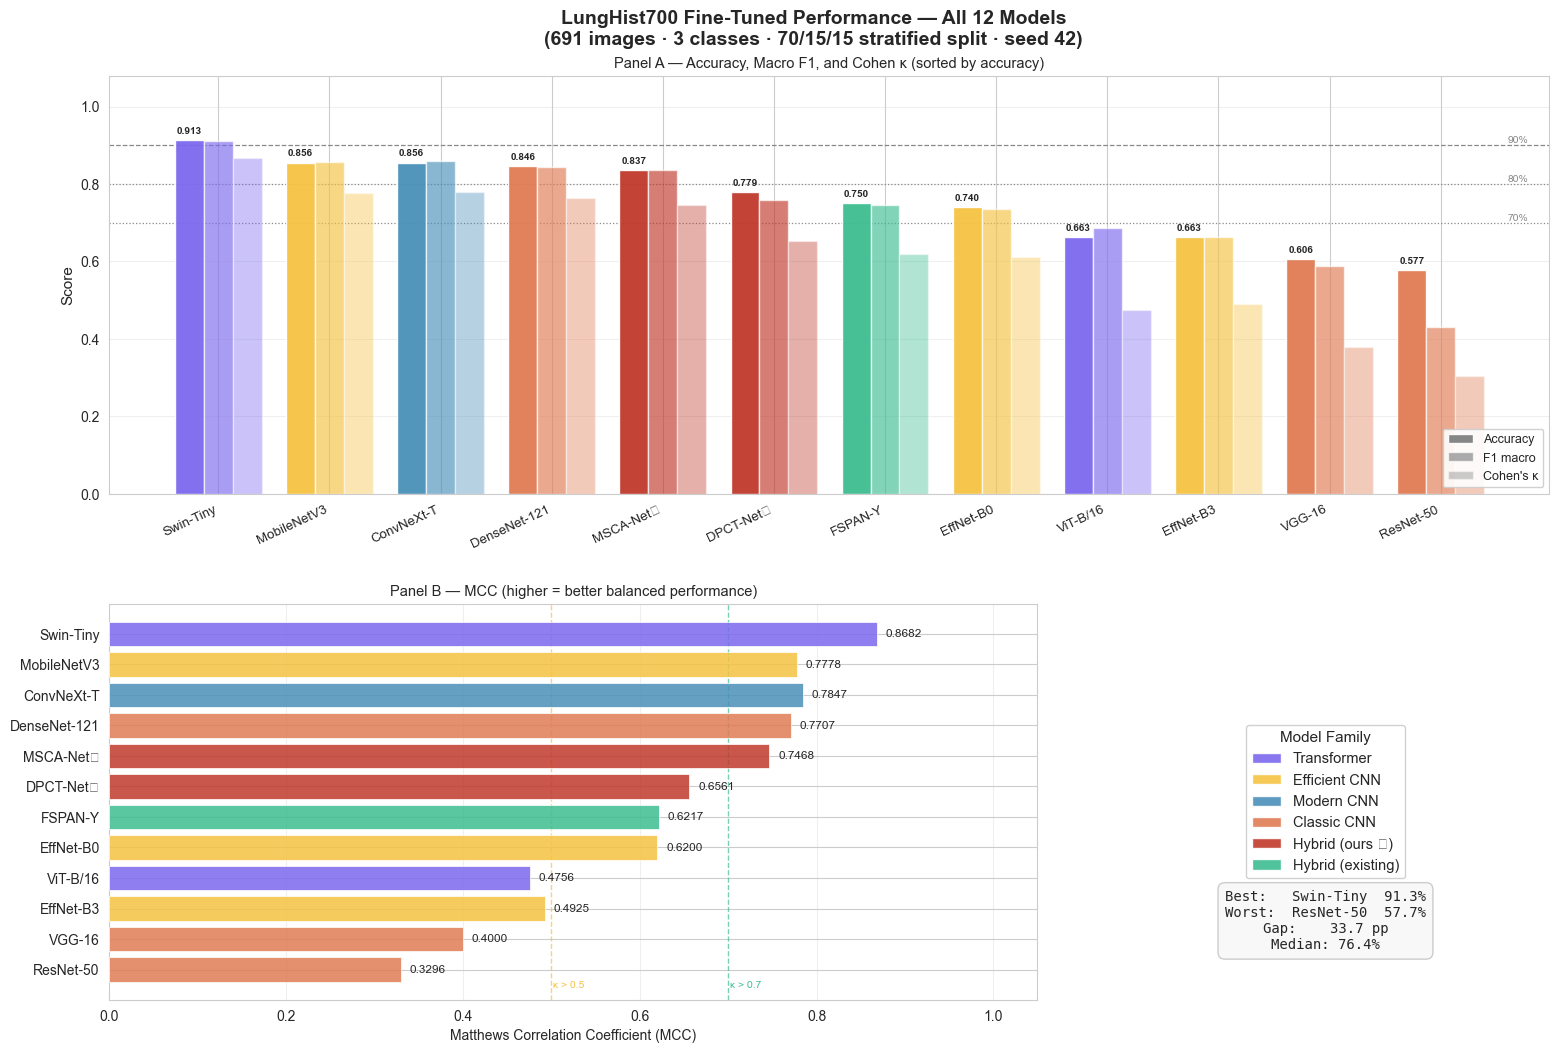

✅ Saved → E:\LC25000_results\figures\lunghist700_finetuned_results.png


In [69]:
# =====================================================================
# Section 11 — LungHist700 Fine-Tuned Results: Publication Plot
# =====================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── data (auto-built from lh_metrics) ────────────────────────────────
names  = list(lh_df.index)          # already sorted by accuracy (desc)
acc    = [lh_metrics[n]['accuracy']        for n in names]
f1     = [lh_metrics[n]['f1_macro']        for n in names]
kappa  = [lh_metrics[n]['cohen_kappa']     for n in names]
mcc    = [lh_metrics[n]['mcc']             for n in names]

# ── model-family colour map ───────────────────────────────────────────
FAMILY = {
    'VGG16':          ('Classic CNN',       '#E07B54'),
    'ResNet50':       ('Classic CNN',       '#E07B54'),
    'DenseNet121':    ('Classic CNN',       '#E07B54'),
    'MobileNetV3':    ('Efficient CNN',     '#F5C242'),
    'EfficientNet_B0':('Efficient CNN',     '#F5C242'),
    'EfficientNet_B3':('Efficient CNN',     '#F5C242'),
    'ConvNeXt_Tiny':  ('Modern CNN',        '#4A90B8'),
    'ViT_Base':       ('Transformer',       '#7B68EE'),
    'Swin_Tiny':      ('Transformer',       '#7B68EE'),
    'FSPAN_Y':        ('Hybrid (existing)', '#3DBD91'),
    'DPCT_Net':       ('Hybrid (ours ★)',   '#C0392B'),
    'MSCA_Net':       ('Hybrid (ours ★)',   '#C0392B'),
}
bar_colors = [FAMILY.get(n, ('Other', '#999999'))[1] for n in names]

# ── short display labels ──────────────────────────────────────────────
LABELS = {
    'VGG16': 'VGG-16', 'ResNet50': 'ResNet-50',
    'DenseNet121': 'DenseNet-121', 'MobileNetV3': 'MobileNetV3',
    'EfficientNet_B0': 'EffNet-B0', 'EfficientNet_B3': 'EffNet-B3',
    'ConvNeXt_Tiny': 'ConvNeXt-T', 'ViT_Base': 'ViT-B/16',
    'Swin_Tiny': 'Swin-Tiny', 'FSPAN_Y': 'FSPAN-Y',
    'DPCT_Net': 'DPCT-Net★', 'MSCA_Net': 'MSCA-Net★',
}
xlabels = [LABELS.get(n, n) for n in names]

# ── figure layout: 2 rows ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 11))
fig.suptitle(
    'LungHist700 Fine-Tuned Performance — All 12 Models\n'
    '(691 images · 3 classes · 70/15/15 stratified split · seed 42)',
    fontsize=14, fontweight='bold', y=0.98
)

# ── PANEL A: grouped bar chart (Acc / F1 / κ) ────────────────────────
ax1 = fig.add_axes([0.06, 0.54, 0.90, 0.38])

x   = np.arange(len(names))
w   = 0.26

bars_acc   = ax1.bar(x - w,   acc,   w, label='Accuracy',    color=bar_colors, alpha=0.95, zorder=3)
bars_f1    = ax1.bar(x,       f1,    w, label='F1 macro',    color=bar_colors, alpha=0.65, zorder=3)
bars_kappa = ax1.bar(x + w,   kappa, w, label="Cohen's κ",   color=bar_colors, alpha=0.40, zorder=3)

# value labels on accuracy bars only (to avoid clutter)
for bar, v in zip(bars_acc, acc):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
             f'{v:.3f}', ha='center', va='bottom', fontsize=7.2, fontweight='bold')

# threshold lines
for thresh, ls, lbl in [(0.90, '--', '90%'), (0.80, ':', '80%'), (0.70, ':', '70%')]:
    ax1.axhline(thresh, color='#888888', linewidth=0.9, linestyle=ls, zorder=1)
    ax1.text(len(names)-0.4, thresh+0.006, lbl, fontsize=7.5, color='#888888')

ax1.set_xticks(x)
ax1.set_xticklabels(xlabels, rotation=25, ha='right', fontsize=9.5)
ax1.set_ylim(0, 1.08)
ax1.set_ylabel('Score', fontsize=11)
ax1.set_title('Panel A — Accuracy, Macro F1, and Cohen κ (sorted by accuracy)',
              fontsize=10.5, pad=6)
ax1.grid(axis='y', alpha=0.3, zorder=0)
ax1.set_axisbelow(True)

# opacity legend for metrics
leg_patches = [
    mpatches.Patch(facecolor='grey', alpha=0.95, label='Accuracy'),
    mpatches.Patch(facecolor='grey', alpha=0.65, label='F1 macro'),
    mpatches.Patch(facecolor='grey', alpha=0.40, label="Cohen's κ"),
]
ax1.legend(handles=leg_patches, loc='lower right', fontsize=9, framealpha=0.9)

# ── PANEL B: MCC dot-plot ─────────────────────────────────────────────
ax2 = fig.add_axes([0.06, 0.08, 0.58, 0.36])

ax2.barh(xlabels[::-1], mcc[::-1], color=bar_colors[::-1], alpha=0.85,
         edgecolor='white', linewidth=0.6, zorder=3)

for i, (v, n) in enumerate(zip(mcc[::-1], names[::-1])):
    ax2.text(v + 0.010, i, f'{v:.4f}', va='center', fontsize=8.5)

ax2.axvline(0.7,  color='#3DBD91', linewidth=1.0, linestyle='--', alpha=0.7)
ax2.axvline(0.5,  color='#F5C242', linewidth=1.0, linestyle='--', alpha=0.7)
ax2.text(0.702, -0.6, 'κ > 0.7', fontsize=7.5, color='#3DBD91')
ax2.text(0.502, -0.6, 'κ > 0.5', fontsize=7.5, color='#F5C242')

ax2.set_xlim(0, 1.05)
ax2.set_xlabel('Matthews Correlation Coefficient (MCC)', fontsize=10)
ax2.set_title('Panel B — MCC (higher = better balanced performance)',
              fontsize=10.5, pad=6)
ax2.grid(axis='x', alpha=0.3, zorder=0)
ax2.set_axisbelow(True)

# ── PANEL C: family colour legend ────────────────────────────────────
ax3 = fig.add_axes([0.68, 0.08, 0.28, 0.36])
ax3.axis('off')

families = {}
for n in names:
    fam, col = FAMILY.get(n, ('Other', '#999999'))
    if fam not in families:
        families[fam] = col

legend_patches = [
    mpatches.Patch(facecolor=col, label=fam, alpha=0.9)
    for fam, col in families.items()
]
ax3.legend(handles=legend_patches, loc='center', fontsize=10.5,
           framealpha=0.9, title='Model Family', title_fontsize=11,
           edgecolor='#cccccc')

# summary stats annotation
best_n  = names[0]
best_a  = acc[0]
worst_n = names[-1]
worst_a = acc[-1]
ax3.text(0.5, 0.12,
    f'Best:   {LABELS[best_n]}  {best_a:.1%}\n'
    f'Worst:  {LABELS[worst_n]}  {worst_a:.1%}\n'
    f'Gap:    {(best_a - worst_a)*100:.1f} pp\n'
    f'Median: {np.median(acc)*100:.1f}%',
    transform=ax3.transAxes, ha='center', va='bottom',
    fontsize=10, family='monospace',
    bbox=dict(boxstyle='round,pad=0.5', fc='#f8f8f8', ec='#cccccc')
)

# ── save ──────────────────────────────────────────────────────────────
fig_path = OUT_DIR / 'figures' / 'lunghist700_finetuned_results.png'
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✅ Saved → {fig_path}")

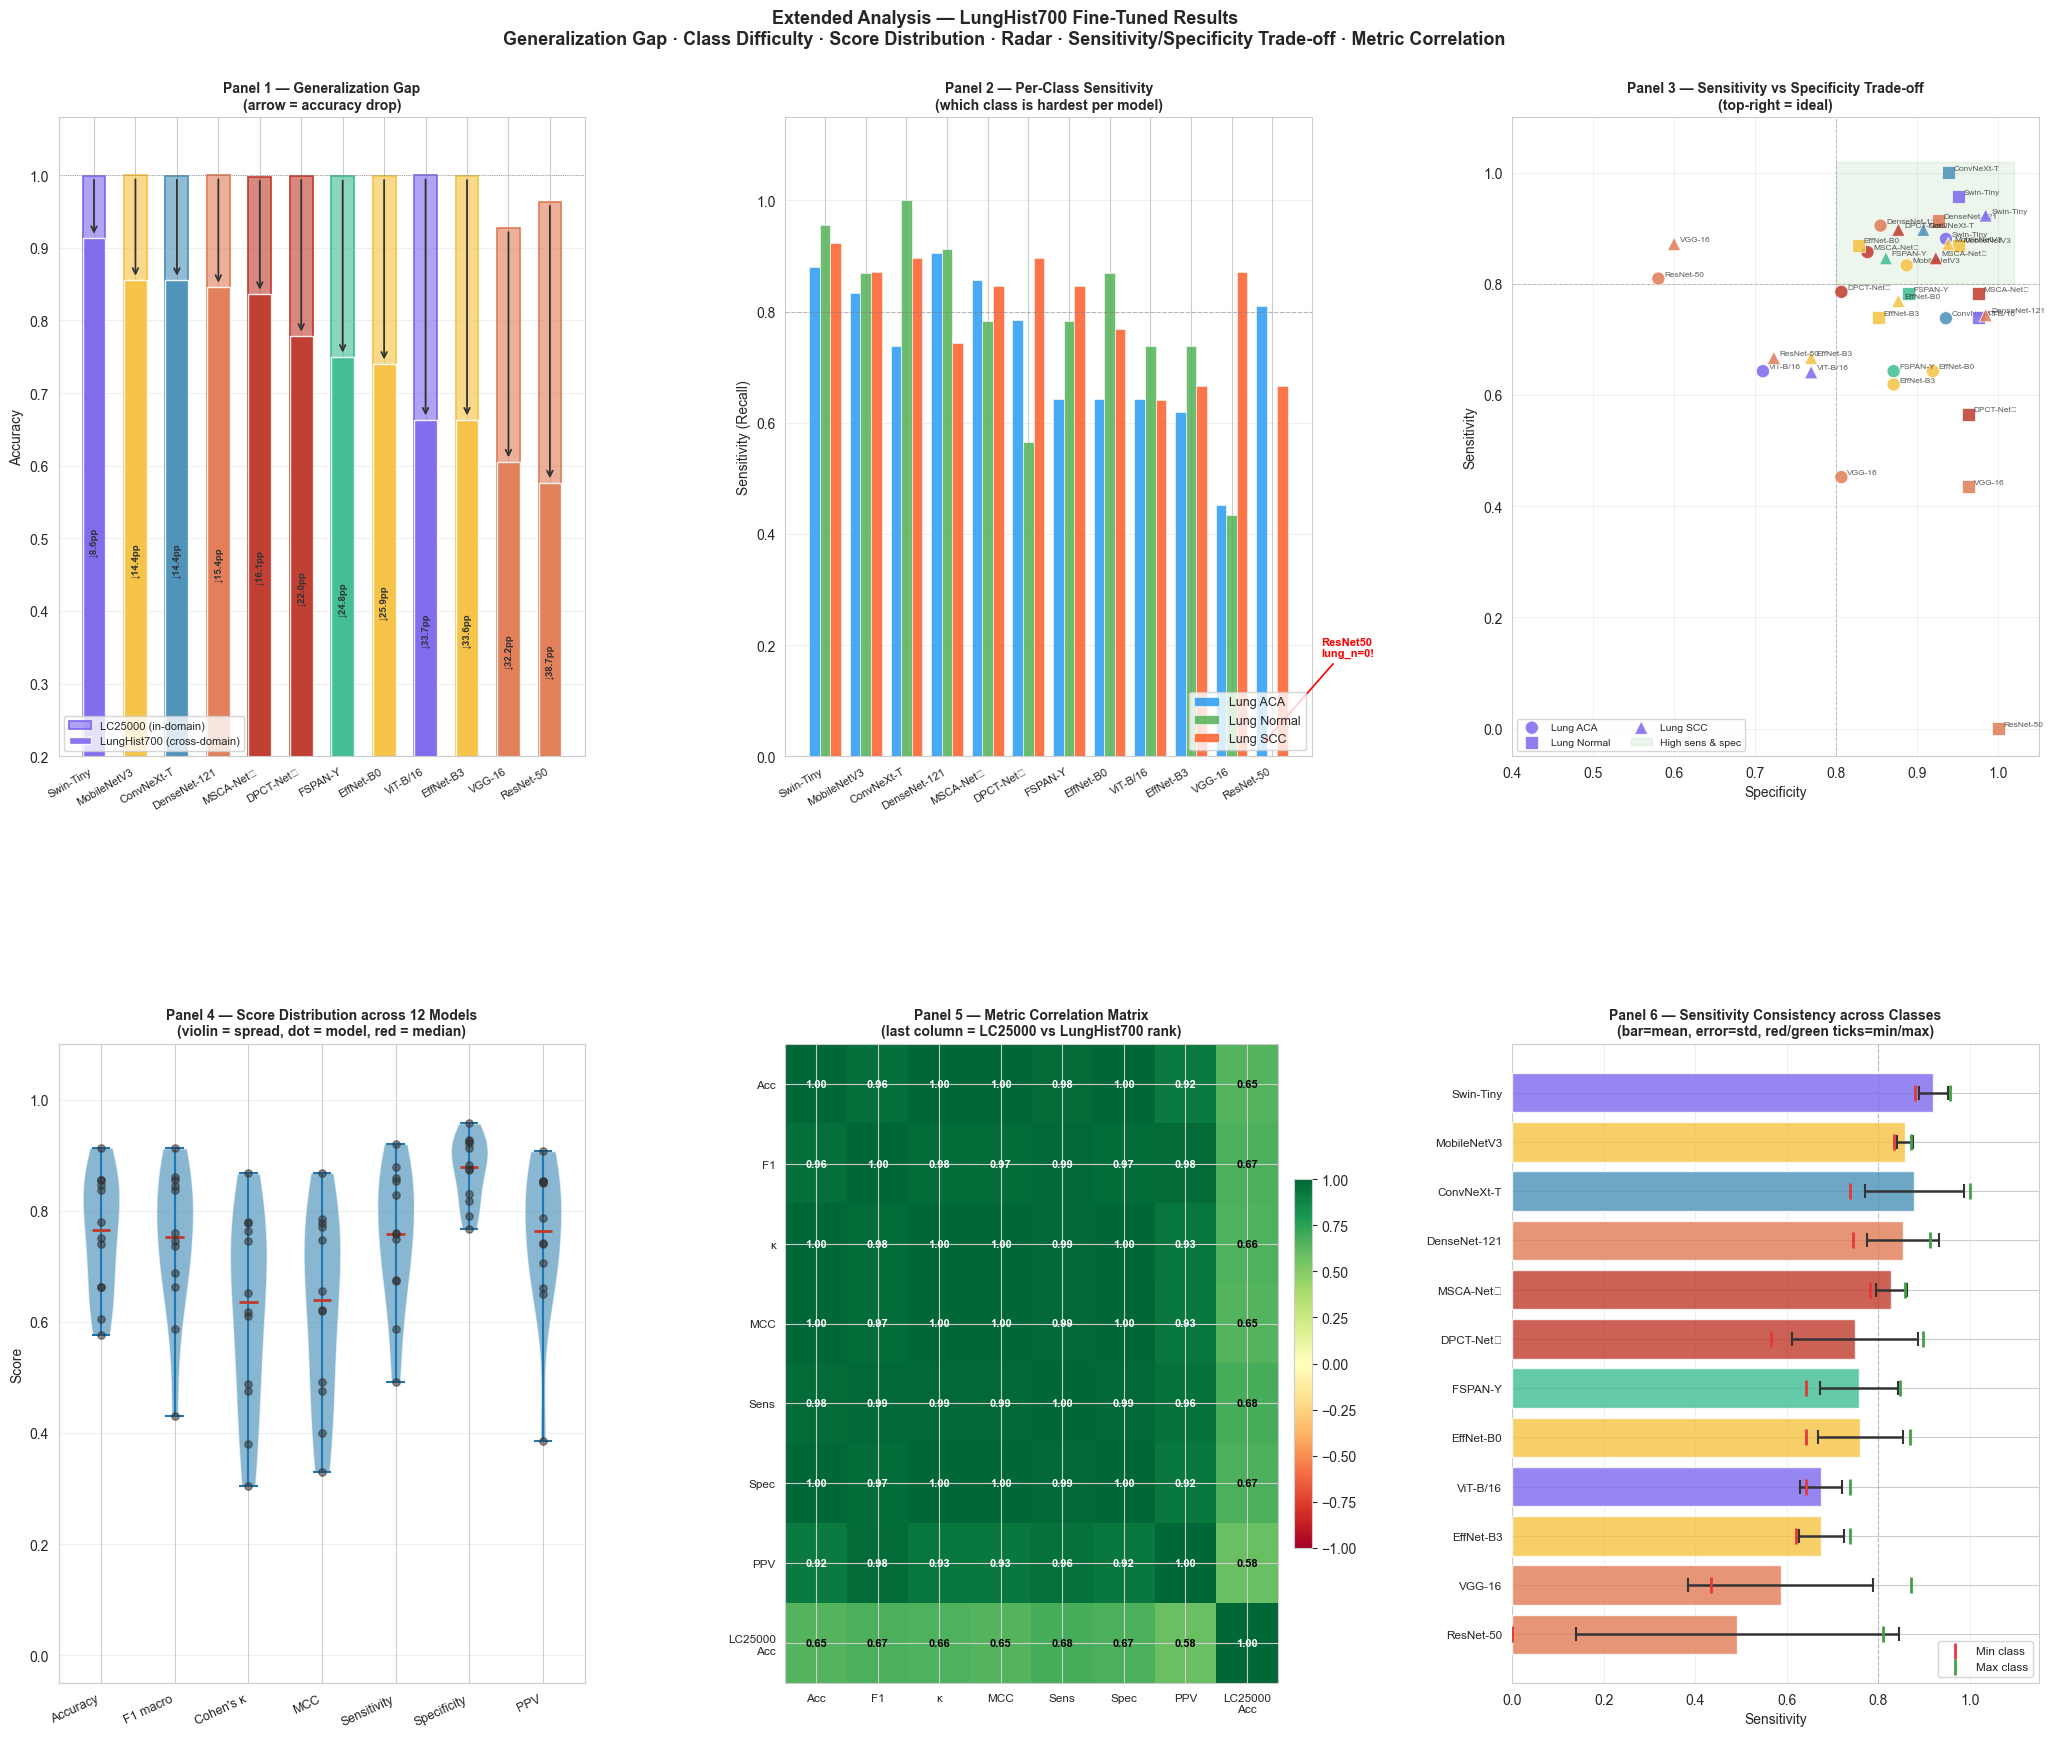

✅ Saved → E:\LC25000_results\figures\lunghist700_extended_analysis.png


In [74]:
# =====================================================================
# Section 11 — Extended Analysis Plots (6 panels)
# =====================================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np
from scipy import stats          # for Pearson r

# ── data assembly ─────────────────────────────────────────────────────
MODEL_ORDER = list(lh_df.index)   # best → worst on LungHist700
CLASSES     = ['lung_aca', 'lung_n', 'lung_scc']
CLASS_LABELS= ['Lung ACA', 'Lung Normal', 'Lung SCC']
LABELS = {
    'VGG16':'VGG-16','ResNet50':'ResNet-50','DenseNet121':'DenseNet-121',
    'MobileNetV3':'MobileNetV3','EfficientNet_B0':'EffNet-B0',
    'EfficientNet_B3':'EffNet-B3','ConvNeXt_Tiny':'ConvNeXt-T',
    'ViT_Base':'ViT-B/16','Swin_Tiny':'Swin-Tiny',
    'FSPAN_Y':'FSPAN-Y','DPCT_Net':'DPCT-Net★','MSCA_Net':'MSCA-Net★',
}
FAMILY_COLOR = {
    'VGG16':'#E07B54','ResNet50':'#E07B54','DenseNet121':'#E07B54',
    'MobileNetV3':'#F5C242','EfficientNet_B0':'#F5C242','EfficientNet_B3':'#F5C242',
    'ConvNeXt_Tiny':'#4A90B8','ViT_Base':'#7B68EE','Swin_Tiny':'#7B68EE',
    'FSPAN_Y':'#3DBD91','DPCT_Net':'#C0392B','MSCA_Net':'#C0392B',
}
colors = [FAMILY_COLOR[n] for n in MODEL_ORDER]
xlabels = [LABELS[n] for n in MODEL_ORDER]

# LC25000 accuracies (in-domain — pulled dynamically from all_metrics)
lc25000_acc = {name: all_metrics[name]['accuracy'] for name in MODEL_ORDER}
lh_acc    = {n: lh_metrics[n]['accuracy']    for n in MODEL_ORDER}
lh_f1     = {n: lh_metrics[n]['f1_macro']    for n in MODEL_ORDER}
lh_kappa  = {n: lh_metrics[n]['cohen_kappa'] for n in MODEL_ORDER}
lh_mcc    = {n: lh_metrics[n]['mcc']         for n in MODEL_ORDER}

# ── per-class helpers ─────────────────────────────────────────────────
def get_metric(metric):
    grid = np.zeros((len(MODEL_ORDER), 3))
    for r, name in enumerate(MODEL_ORDER):
        for c, cls in enumerate(CLASSES):
            row = lh_tpfp_df[(lh_tpfp_df['Model']==name) &
                             (lh_tpfp_df['Class']==cls)]
            if not row.empty:
                grid[r, c] = float(row[metric].values[0])
    return grid

sens_g = get_metric('Sensitivity')
spec_g = get_metric('Specificity')
ppv_g  = get_metric('PPV')

# ── figure ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 18))
fig.suptitle(
    'Extended Analysis — LungHist700 Fine-Tuned Results\n'
    'Generalization Gap · Class Difficulty · Score Distribution · '
    'Radar · Sensitivity/Specificity Trade-off · Metric Correlation',
    fontsize=13, fontweight='bold', y=0.99
)
gs = gridspec.GridSpec(2, 3, figure=fig,
                       hspace=0.45, wspace=0.38,
                       left=0.07, right=0.97,
                       top=0.93, bottom=0.06)

# ══════════════════════════════════════════════════════════════════════
# PANEL 1 — Generalization gap: LC25000 vs LungHist700
# ══════════════════════════════════════════════════════════════════════
ax1 = fig.add_subplot(gs[0, 0])
lc_vals = [lc25000_acc[n] for n in MODEL_ORDER]
lh_vals = [lh_acc[n]      for n in MODEL_ORDER]
gaps    = [lc - lh for lc, lh in zip(lc_vals, lh_vals)]
x = np.arange(len(MODEL_ORDER))

ax1.bar(x, lc_vals, 0.55, label='LC25000 (in-domain)',
        color=[c+'99' for c in colors], edgecolor=colors, linewidth=1.2)
ax1.bar(x, lh_vals, 0.55, label='LungHist700 (cross-domain)',
        color=colors, alpha=0.90)

for i, (lc, lh, g) in enumerate(zip(lc_vals, lh_vals, gaps)):
    ax1.annotate('', xy=(i, lh+0.002), xytext=(i, lc-0.002),
                 arrowprops=dict(arrowstyle='->', color='#333333',
                                 lw=1.3, mutation_scale=10))
    ax1.text(i, min(lc, lh)/2 + 0.02, f'↓{g*100:.1f}pp',
             ha='center', fontsize=7.0, color='#333333', fontweight='bold',
             rotation=90)

ax1.set_xticks(x); ax1.set_xticklabels(xlabels, rotation=30, ha='right', fontsize=8)
ax1.set_ylim(0.2, 1.08); ax1.set_ylabel('Accuracy')
ax1.set_title('Panel 1 — Generalization Gap\n(arrow = accuracy drop)', fontsize=10, fontweight='bold')
ax1.legend(fontsize=8, loc='lower left')
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(1.0, color='grey', lw=0.6, ls=':')

# ══════════════════════════════════════════════════════════════════════
# PANEL 2 — Per-class sensitivity comparison (grouped)
# ══════════════════════════════════════════════════════════════════════
ax2 = fig.add_subplot(gs[0, 1])
w = 0.26
CLASS_COLORS = ['#2196F3', '#4CAF50', '#FF5722']
for ci, (cls, clbl, clr) in enumerate(zip(CLASSES, CLASS_LABELS, CLASS_COLORS)):
    vals = sens_g[:, ci]
    bars = ax2.bar(x + (ci-1)*w, vals, w, label=clbl,
                   color=clr, alpha=0.82, edgecolor='white', linewidth=0.5)

ax2.set_xticks(x); ax2.set_xticklabels(xlabels, rotation=30, ha='right', fontsize=8)
ax2.set_ylim(0, 1.15); ax2.set_ylabel('Sensitivity (Recall)')
ax2.set_title('Panel 2 — Per-Class Sensitivity\n(which class is hardest per model)',
              fontsize=10, fontweight='bold')
ax2.legend(fontsize=9, loc='lower right')
ax2.axhline(0.8, color='grey', lw=0.8, ls='--', alpha=0.5)
ax2.grid(axis='y', alpha=0.3)

# ResNet50 zero annotation
rn_idx = MODEL_ORDER.index('ResNet50')
ax2.annotate('ResNet50\nlung_n=0!',
             xy=(rn_idx - w, 0.02), xytext=(rn_idx + 1.2, 0.18),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.2),
             fontsize=8, color='red', fontweight='bold')

# ══════════════════════════════════════════════════════════════════════
# PANEL 3 — Sensitivity–Specificity scatter (trade-off)
# ══════════════════════════════════════════════════════════════════════
ax3 = fig.add_subplot(gs[0, 2])
for ci, (cls, clbl, clr, mkr) in enumerate(zip(
        CLASSES, CLASS_LABELS, CLASS_COLORS, ['o','s','^'])):
    ax3.scatter(spec_g[:, ci], sens_g[:, ci],
                c=[FAMILY_COLOR[n] for n in MODEL_ORDER],
                marker=mkr, s=90, alpha=0.85,
                edgecolors='white', linewidths=0.6,
                label=clbl, zorder=3)
    for r, name in enumerate(MODEL_ORDER):
        ax3.annotate(LABELS[name],
                     (spec_g[r, ci], sens_g[r, ci]),
                     textcoords='offset points', xytext=(4, 2),
                     fontsize=6.0, alpha=0.75)

ax3.axhline(0.8, color='grey', lw=0.7, ls='--', alpha=0.5)
ax3.axvline(0.8, color='grey', lw=0.7, ls='--', alpha=0.5)
ax3.fill_between([0.8, 1.02], [0.8, 0.8], [1.02, 1.02],
                 alpha=0.07, color='green', label='High sens & spec')
ax3.set_xlim(0.4, 1.05); ax3.set_ylim(-0.05, 1.10)
ax3.set_xlabel('Specificity'); ax3.set_ylabel('Sensitivity')
ax3.set_title('Panel 3 — Sensitivity vs Specificity Trade-off\n(top-right = ideal)',
              fontsize=10, fontweight='bold')
ax3.legend(fontsize=7.5, loc='lower left', ncol=2)
ax3.grid(alpha=0.25)

# ══════════════════════════════════════════════════════════════════════
# PANEL 4 — Score distribution violin
# ══════════════════════════════════════════════════════════════════════
ax4 = fig.add_subplot(gs[1, 0])
metrics_for_violin = {
    'Accuracy':    [lh_acc[n]   for n in MODEL_ORDER],
    'F1 macro':    [lh_f1[n]    for n in MODEL_ORDER],
    "Cohen's κ":   [lh_kappa[n] for n in MODEL_ORDER],
    'MCC':         [lh_mcc[n]   for n in MODEL_ORDER],
    'Sensitivity': list(sens_g.mean(axis=1)),
    'Specificity': list(spec_g.mean(axis=1)),
    'PPV':         list(ppv_g.mean(axis=1)),
}
vp = ax4.violinplot(list(metrics_for_violin.values()),
                    positions=range(len(metrics_for_violin)),
                    showmedians=True, showextrema=True)
for body in vp['bodies']:
    body.set_facecolor('#4A90B8'); body.set_alpha(0.65)
vp['cmedians'].set_color('#C0392B'); vp['cmedians'].set_linewidth(2)

for i, vals in enumerate(metrics_for_violin.values()):
    ax4.scatter([i]*len(vals), vals, s=28, color='#333333',
                alpha=0.55, zorder=3)

ax4.set_xticks(range(len(metrics_for_violin)))
ax4.set_xticklabels(list(metrics_for_violin.keys()),
                    rotation=25, ha='right', fontsize=9)
ax4.set_ylim(-0.05, 1.10); ax4.set_ylabel('Score')
ax4.set_title('Panel 4 — Score Distribution across 12 Models\n(violin = spread, dot = model, red = median)',
              fontsize=10, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# ══════════════════════════════════════════════════════════════════════
# PANEL 5 — Metric correlation matrix (heatmap)
# ══════════════════════════════════════════════════════════════════════
ax5 = fig.add_subplot(gs[1, 1])
metric_matrix = np.column_stack([
    [lh_acc[n]                for n in MODEL_ORDER],
    [lh_f1[n]                 for n in MODEL_ORDER],
    [lh_kappa[n]              for n in MODEL_ORDER],
    [lh_mcc[n]                for n in MODEL_ORDER],
    list(sens_g.mean(axis=1)),
    list(spec_g.mean(axis=1)),
    list(ppv_g.mean(axis=1)),
    [lc25000_acc[n]           for n in MODEL_ORDER],
])
mlabels = ['Acc','F1','κ','MCC','Sens','Spec','PPV','LC25000\nAcc']
corr = np.corrcoef(metric_matrix.T)
im = ax5.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax5.set_xticks(range(len(mlabels))); ax5.set_xticklabels(mlabels, fontsize=8.5)
ax5.set_yticks(range(len(mlabels))); ax5.set_yticklabels(mlabels, fontsize=8.5)
for r in range(len(mlabels)):
    for c in range(len(mlabels)):
        v = corr[r, c]
        color = 'white' if abs(v) > 0.7 else 'black'
        ax5.text(c, r, f'{v:.2f}', ha='center', va='center',
                 fontsize=8, color=color, fontweight='bold')
plt.colorbar(im, ax=ax5, fraction=0.035, pad=0.03)
ax5.set_title('Panel 5 — Metric Correlation Matrix\n(last column = LC25000 vs LungHist700 rank)',
              fontsize=10, fontweight='bold')

# ══════════════════════════════════════════════════════════════════════
# PANEL 6 — Consistency: Sensitivity range across classes (error bar)
# ══════════════════════════════════════════════════════════════════════
ax6 = fig.add_subplot(gs[1, 2])
mean_s  = sens_g.mean(axis=1)
std_s   = sens_g.std(axis=1)
min_s   = sens_g.min(axis=1)
max_s   = sens_g.max(axis=1)

ax6.barh(range(len(MODEL_ORDER)), mean_s[::-1],
         color=colors[::-1], alpha=0.80, zorder=3)
ax6.errorbar(mean_s[::-1], range(len(MODEL_ORDER)),
             xerr=std_s[::-1], fmt='none',
             ecolor='#333333', elinewidth=1.8,
             capsize=5, capthick=1.5, zorder=4)
ax6.scatter(min_s[::-1], range(len(MODEL_ORDER)),
            marker='|', s=120, color='#E53935',
            linewidths=2, zorder=5, label='Min class')
ax6.scatter(max_s[::-1], range(len(MODEL_ORDER)),
            marker='|', s=120, color='#43A047',
            linewidths=2, zorder=5, label='Max class')

ax6.set_yticks(range(len(MODEL_ORDER)))
ax6.set_yticklabels(xlabels[::-1], fontsize=8.5)
ax6.set_xlim(0, 1.15)
ax6.set_xlabel('Sensitivity')
ax6.set_title('Panel 6 — Sensitivity Consistency across Classes\n'
              '(bar=mean, error=std, red/green ticks=min/max)',
              fontsize=10, fontweight='bold')
ax6.axvline(0.8, color='grey', lw=0.8, ls='--', alpha=0.5)
ax6.legend(fontsize=8.5, loc='lower right')
ax6.grid(axis='x', alpha=0.3)

# ── save ──────────────────────────────────────────────────────────────
fig_path = OUT_DIR / 'figures' / 'lunghist700_extended_analysis.png'
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✅ Saved → {fig_path}")